In [1]:
# - Librairies -----
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from nucleo.io.reading import reading_all_parquet

In [12]:
# - Getting the data -----
root_fact = "/home/nicolas/Documents/Workspace/nucleo/outputs/FACT__PSMN__2026-05-21"
# root_fact = "/home/nicolas/Documents/Workspace/nucleo/outputs/FACT__PC__2026-09-16"

df_fact = reading_all_parquet(root_fact)
df_fact.group_by(["mode", "land", "l", "alphar", "Kp"])
print(df_fact)

shape: (5_346, 61)
┌──────┬──────┬──────────┬───────┬───┬───────┬──────────┬──────────┬───────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ dx_mp ┆ dt_mean  ┆ dt_med   ┆ dt_mp │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---   ┆ ---      ┆ ---      ┆ ---   │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ f64   ┆ f64      ┆ f64      ┆ f64   │
╞══════╪══════╪══════════╪═══════╪═══╪═══════╪══════════╪══════════╪═══════╡
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 91.5  ┆ 0.999241 ┆ 0.837845 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 73.5  ┆ 0.996669 ┆ 0.836689 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 98.5  ┆ 0.998465 ┆ 0.838713 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 74.5  ┆ 1.001269 ┆ 0.840778 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 82.5  ┆ 1.000149 ┆ 0.839989 ┆ 0.5   │
│ …    ┆ …    ┆ …        ┆ …     ┆ … ┆ …     ┆ …        ┆ …        ┆ …     │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 85.5  ┆ 1.000216 ┆ 0.83942  ┆ 0.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 77.5  ┆ 1.002424 ┆

# Passive

In [13]:
# - Data -----
df_passive = df_fact.filter(pl.col("mode") == "passfull")
print(df_passive)
print(df_passive.columns)

shape: (1_782, 61)
┌──────┬──────┬──────────┬───────┬───┬───────┬──────────┬──────────┬───────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ dx_mp ┆ dt_mean  ┆ dt_med   ┆ dt_mp │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---   ┆ ---      ┆ ---      ┆ ---   │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ f64   ┆ f64      ┆ f64      ┆ f64   │
╞══════╪══════╪══════════╪═══════╪═══╪═══════╪══════════╪══════════╪═══════╡
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 73.5  ┆ 0.999307 ┆ 0.839748 ┆ 0.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 94.5  ┆ 0.999359 ┆ 0.837357 ┆ 0.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 84.5  ┆ 0.997639 ┆ 0.838089 ┆ 0.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 79.5  ┆ 0.99962  ┆ 0.835572 ┆ 0.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 78.5  ┆ 0.996656 ┆ 0.836929 ┆ 0.5   │
│ …    ┆ …    ┆ …        ┆ …     ┆ … ┆ …     ┆ …        ┆ …        ┆ …     │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 85.5  ┆ 1.000216 ┆ 0.83942  ┆ 0.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 77.5  ┆ 1.002424 ┆

In [14]:
columns = [
    'algo', 'fact', 'mode', 'dstr', 
    'land', 's', 'l', 'bpmin', 
    'mu', 'theta', 'alphaf', 
    'alphao', 'beta', 'rcapt', 'rrest', 'alphac', 'alphad', 
    'alphar', 'krel', 'Kp', 'Kz'
]

for col in columns:
    print(f"Unique values of {col} : {np.unique(df_passive[col])}")

landscapes = ["periodic", "random"]
df_passive = df_passive.filter(
    (pl.col("Kz") == 0.0) &
    (pl.col("land").is_in(landscapes))
)
print(df_passive)

Unique values of algo : ['2S']
Unique values of fact : [ True]
Unique values of mode : ['passfull']
Unique values of dstr : [False]
Unique values of land : ['homogen' 'periodic' 'random']
Unique values of s : [35]
Unique values of l : [ 10  35 100]
Unique values of bpmin : [0]
Unique values of mu : [150]
Unique values of theta : [100]
Unique values of alphaf : [1.]
Unique values of alphao : [0.]
Unique values of beta : [0.]
Unique values of rcapt : [2.]
Unique values of rrest : [2.]
Unique values of alphac : [0.6]
Unique values of alphad : [0.]
Unique values of alphar : [0.  0.2 0.4 0.6 0.8 1. ]
Unique values of krel : [1.]
Unique values of Kp : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Unique values of Kz : [0.  0.5 1. ]
shape: (396, 61)
┌──────┬──────┬──────────┬───────┬───┬───────┬──────────┬──────────┬───────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ dx_mp ┆ dt_mean  ┆ dt_med   ┆ dt_mp │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---   ┆ ---      ┆ ---      ┆ ---   │
│ str  ┆ bool ┆ 

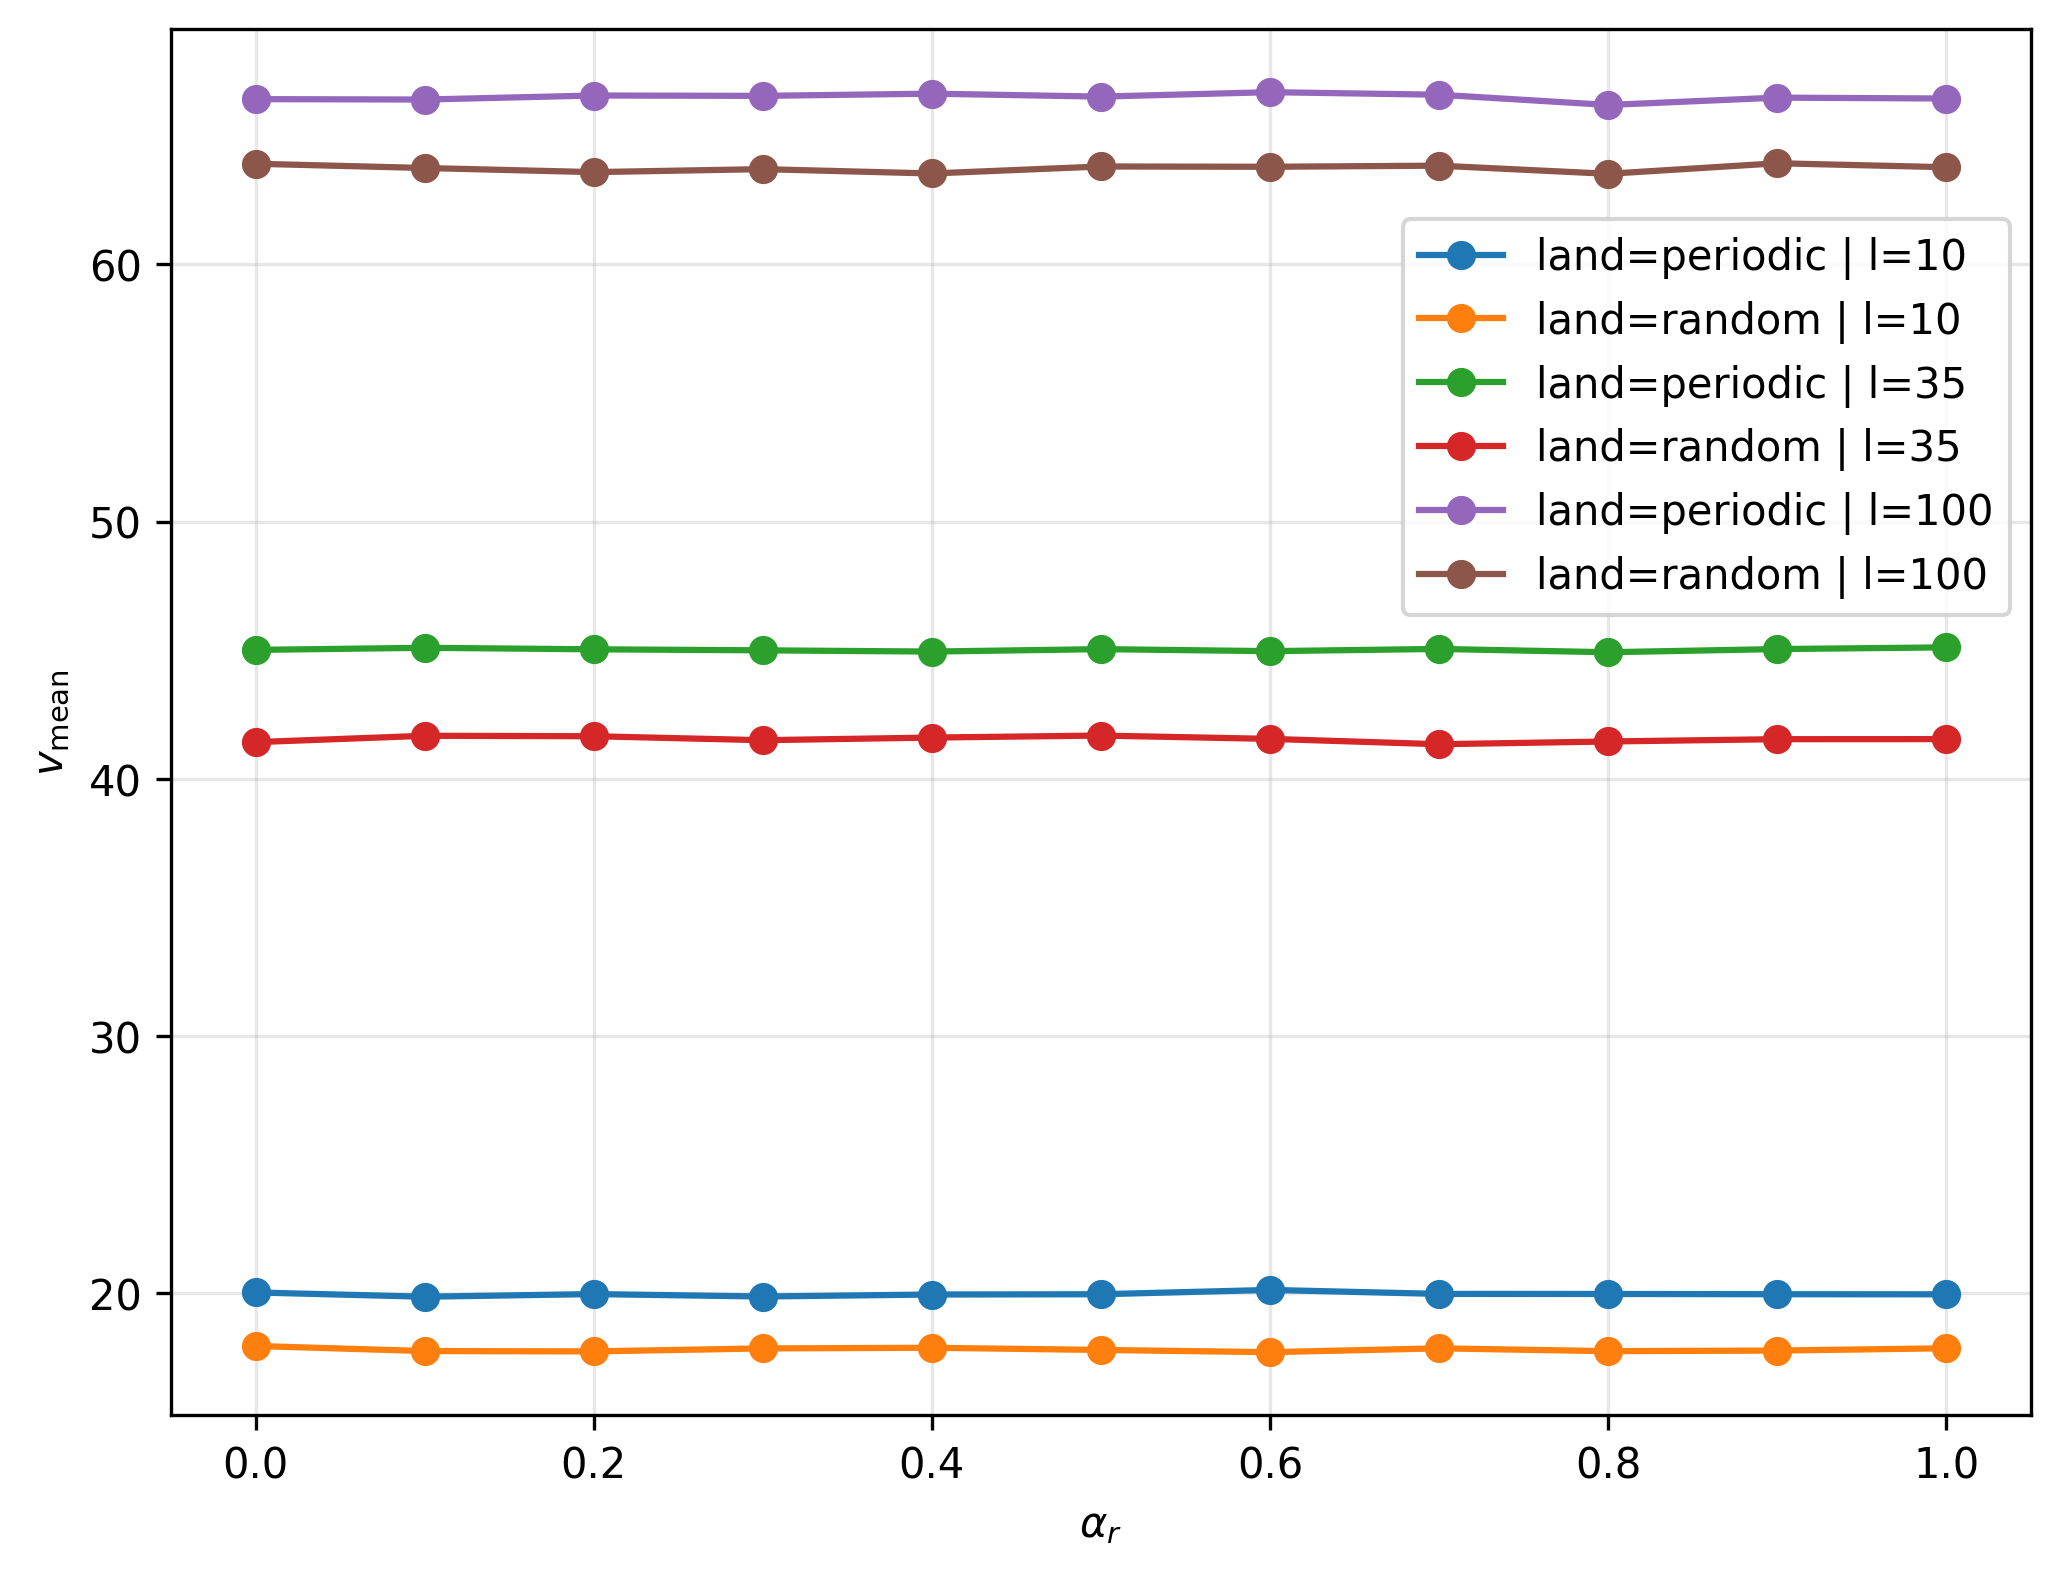

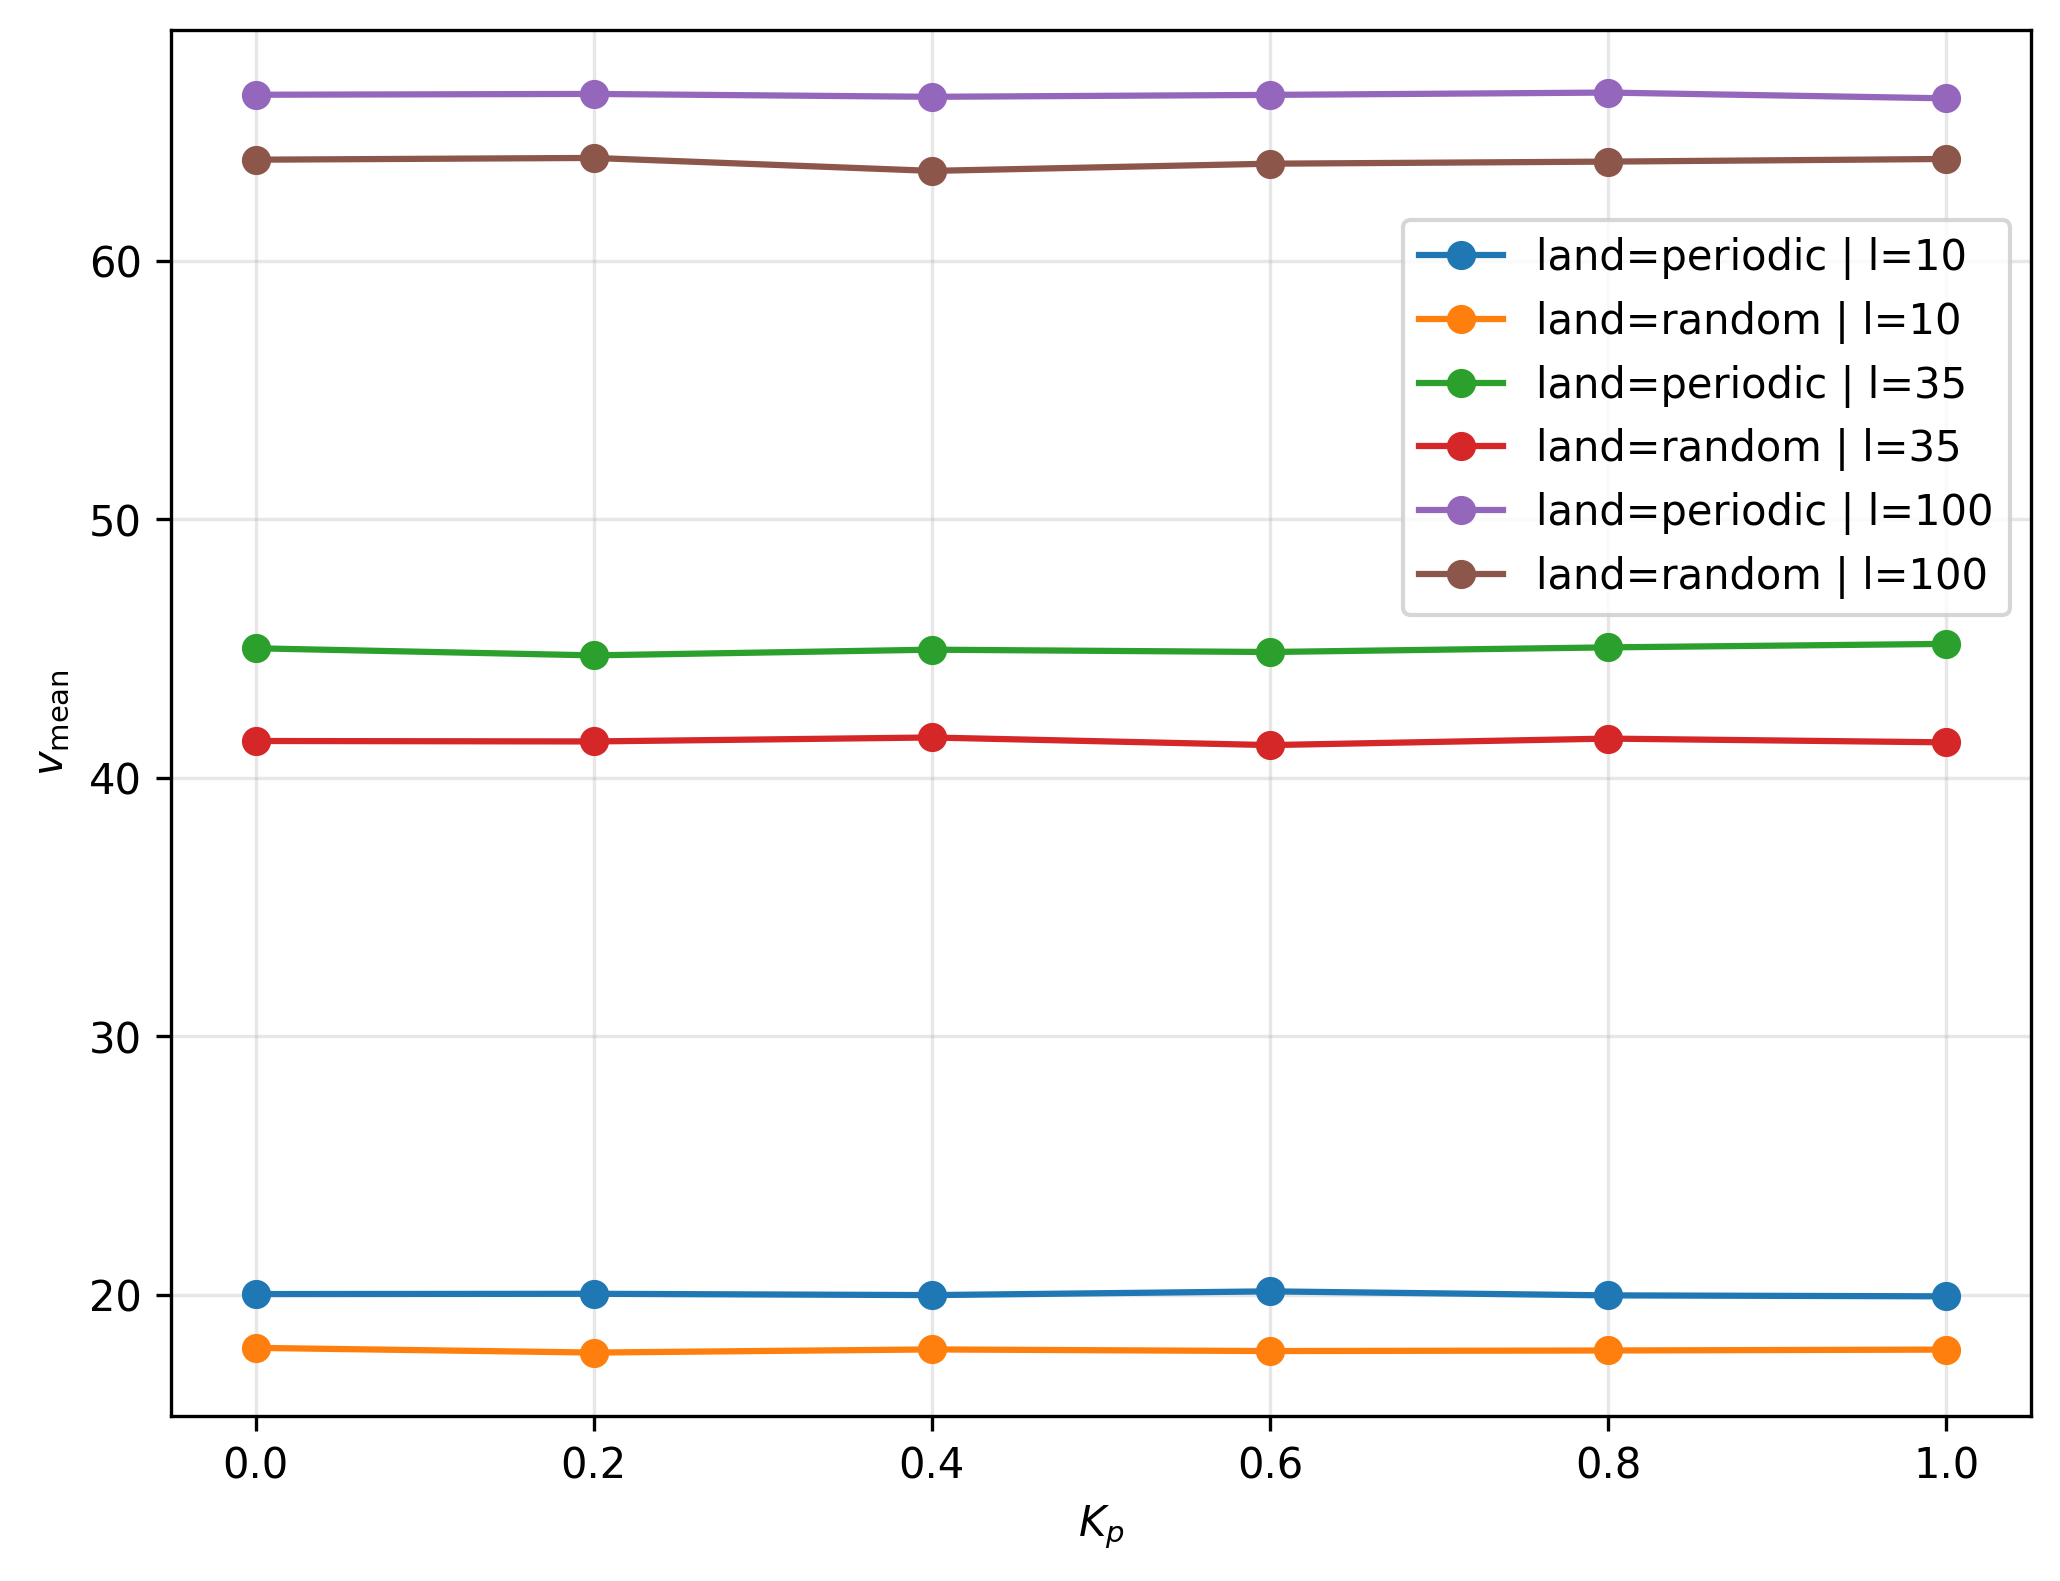

In [15]:
plt.figure(figsize=(8,6), dpi=300)

alphar = 0

ls = np.unique(df_passive["l"].to_numpy())

for l in ls:

    for land in landscapes :

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("alphar") == alphar) &
            (pl.col("l") == l)
        )

        Kp      = df_land["Kp"].to_numpy()
        v_mean  = df_land["v_mean"].to_numpy()

        plt.plot(Kp, v_mean, label=f"land={land} | l={l}", marker = "o")

# plt.title(rf"$l={l}~|~\alpha_r = {alphar}$")
plt.xlabel(r"$\alpha_r$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend(
    loc="center right",
    bbox_to_anchor=(1, 0.72)
)
plt.show()


plt.figure(figsize=(8,6), dpi=300)

Kp = 0
ls = np.unique(df_passive["l"].to_numpy())

for l in ls:

    for land in landscapes :

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("Kp") == Kp) &
            (pl.col("l") == l)
        )

        alphar  = df_land["alphar"].to_numpy()
        v_mean  = df_land["v_mean"].to_numpy()

        plt.plot(alphar, v_mean, label=f"land={land} | l={l}", marker = "o")

# plt.title(rf"$l={l}~|~K_p = {Kp}$")
plt.xlabel(r"$K_p$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend(
    loc="center right",
    bbox_to_anchor=(1, 0.72)
)
plt.show()

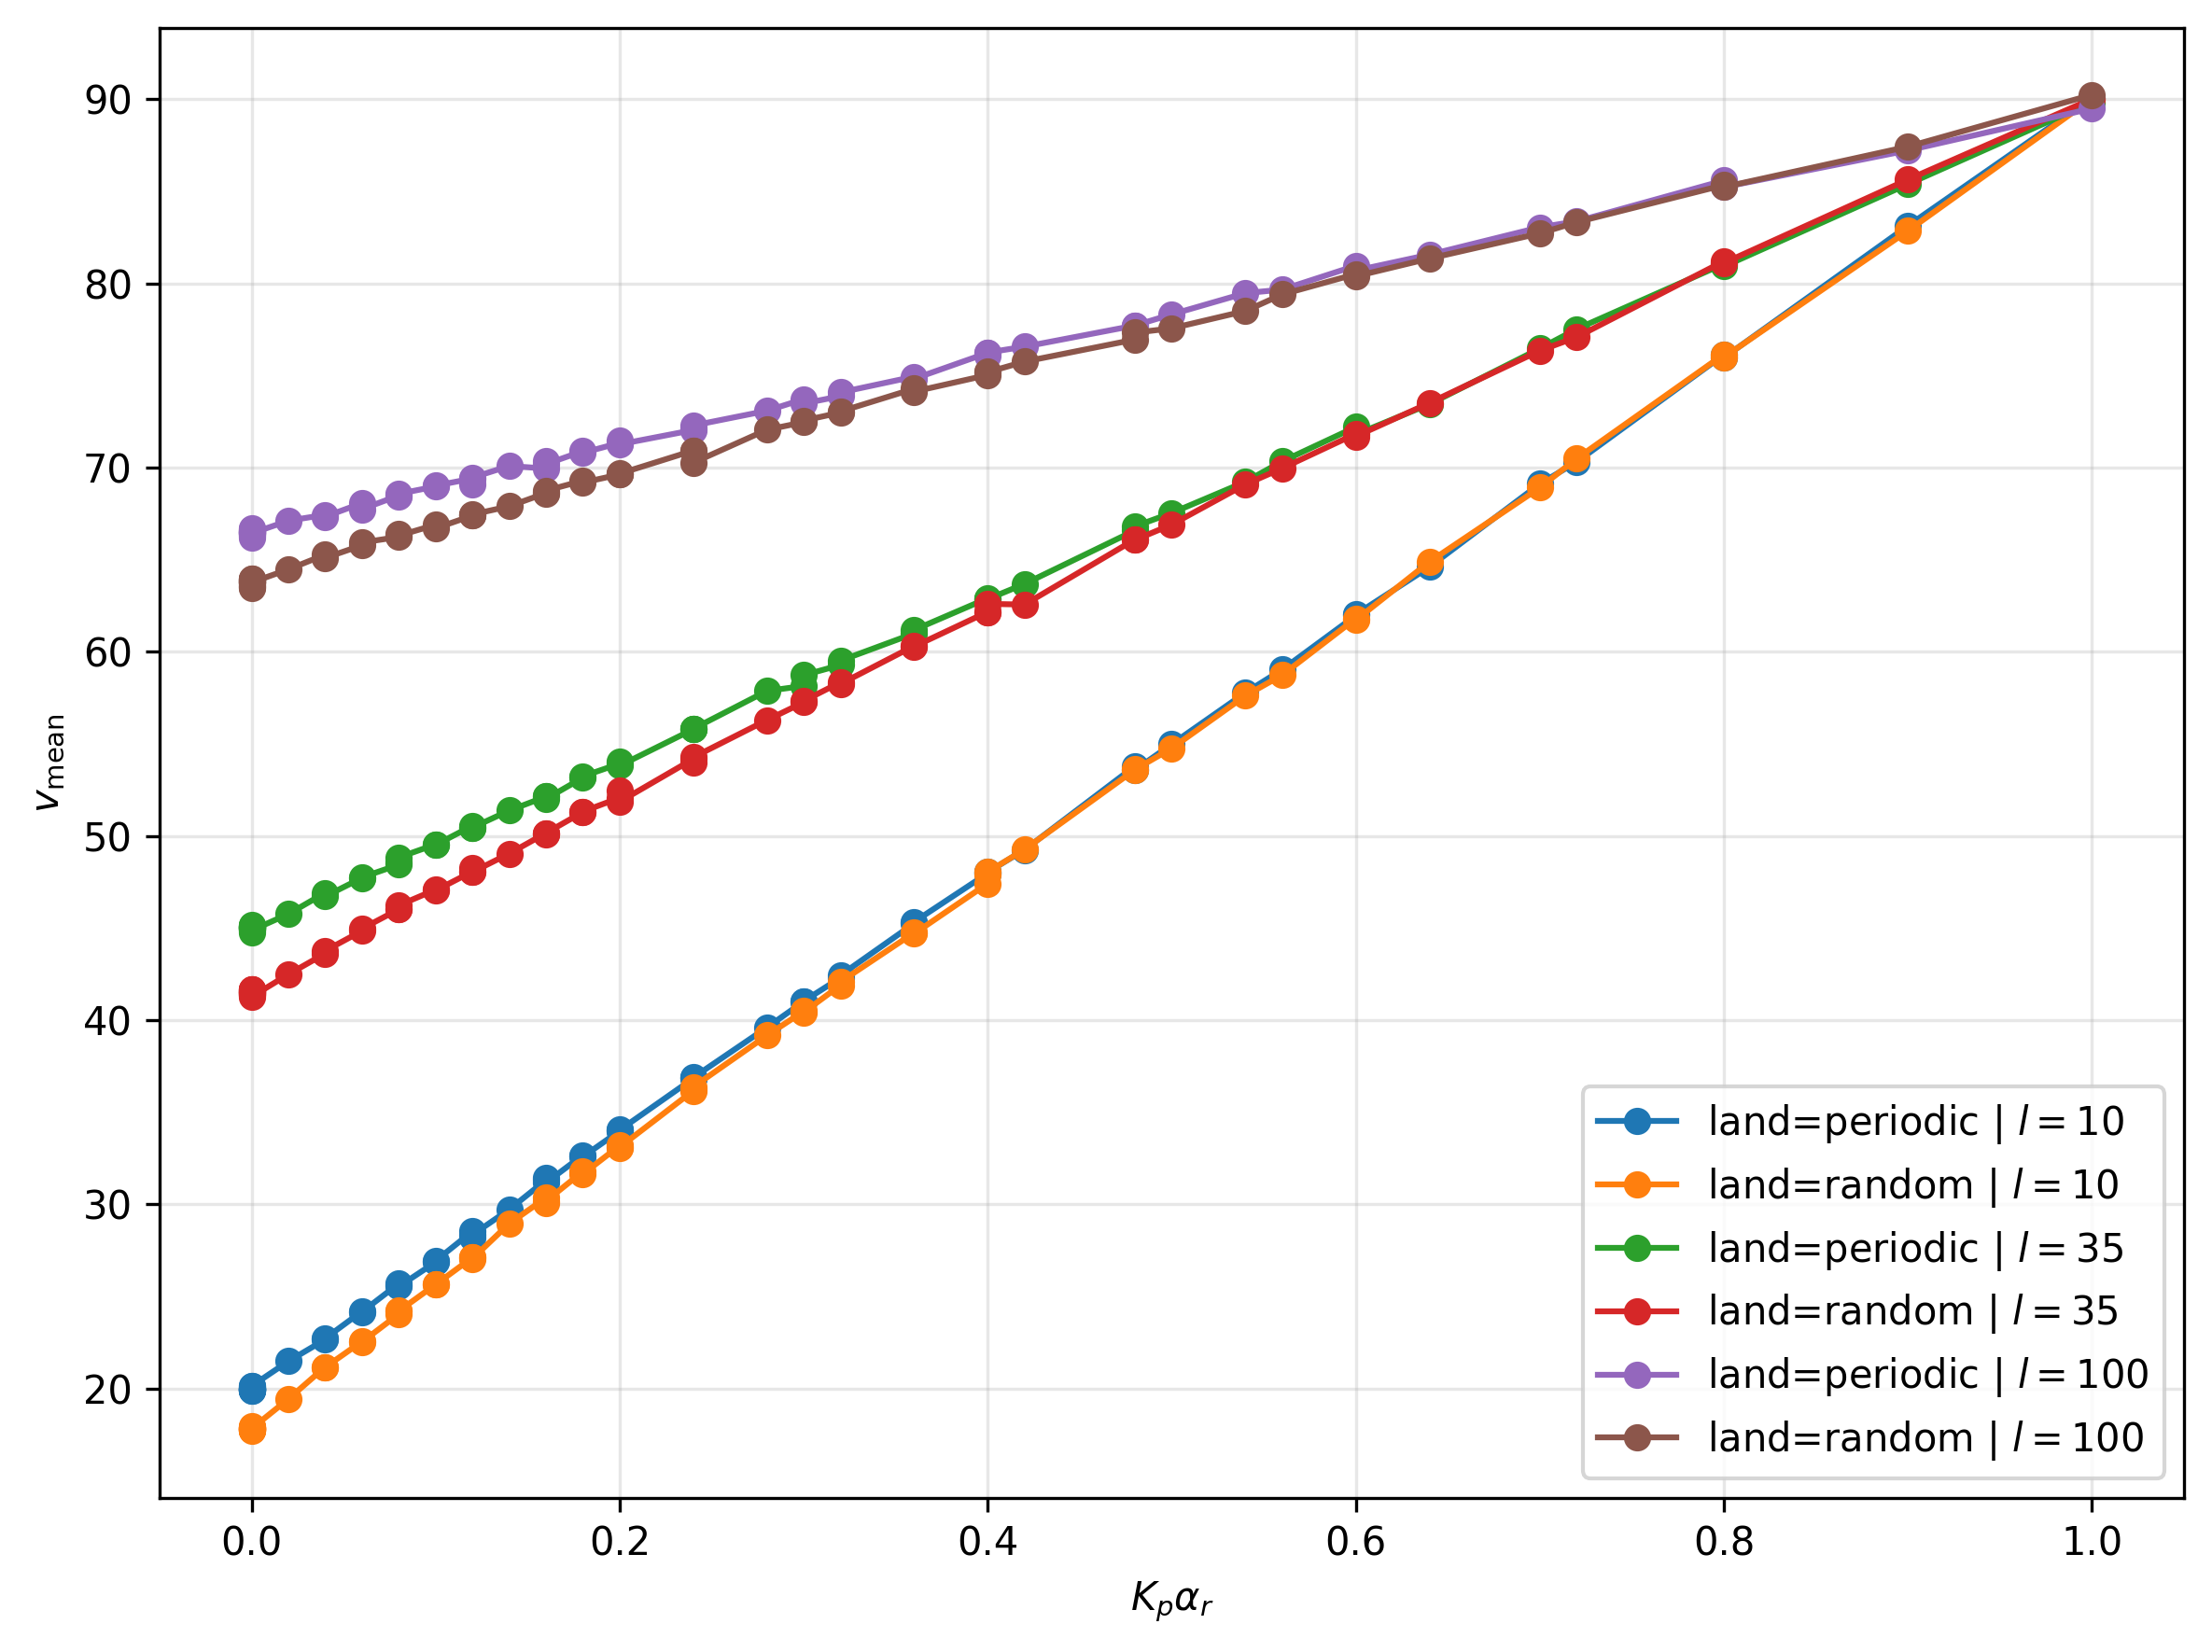

In [16]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

plt.figure(figsize=(8, 6), dpi=300)

ls = np.unique(df_passive["l"].to_numpy())

for l in ls:
    for land in landscapes:

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        v_mean_land = df_land["v_mean"].to_numpy()

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            v_mean_land[order],
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
150 * (10/45) * 0.60

19.999999999999996

66
66
66
66
66
66


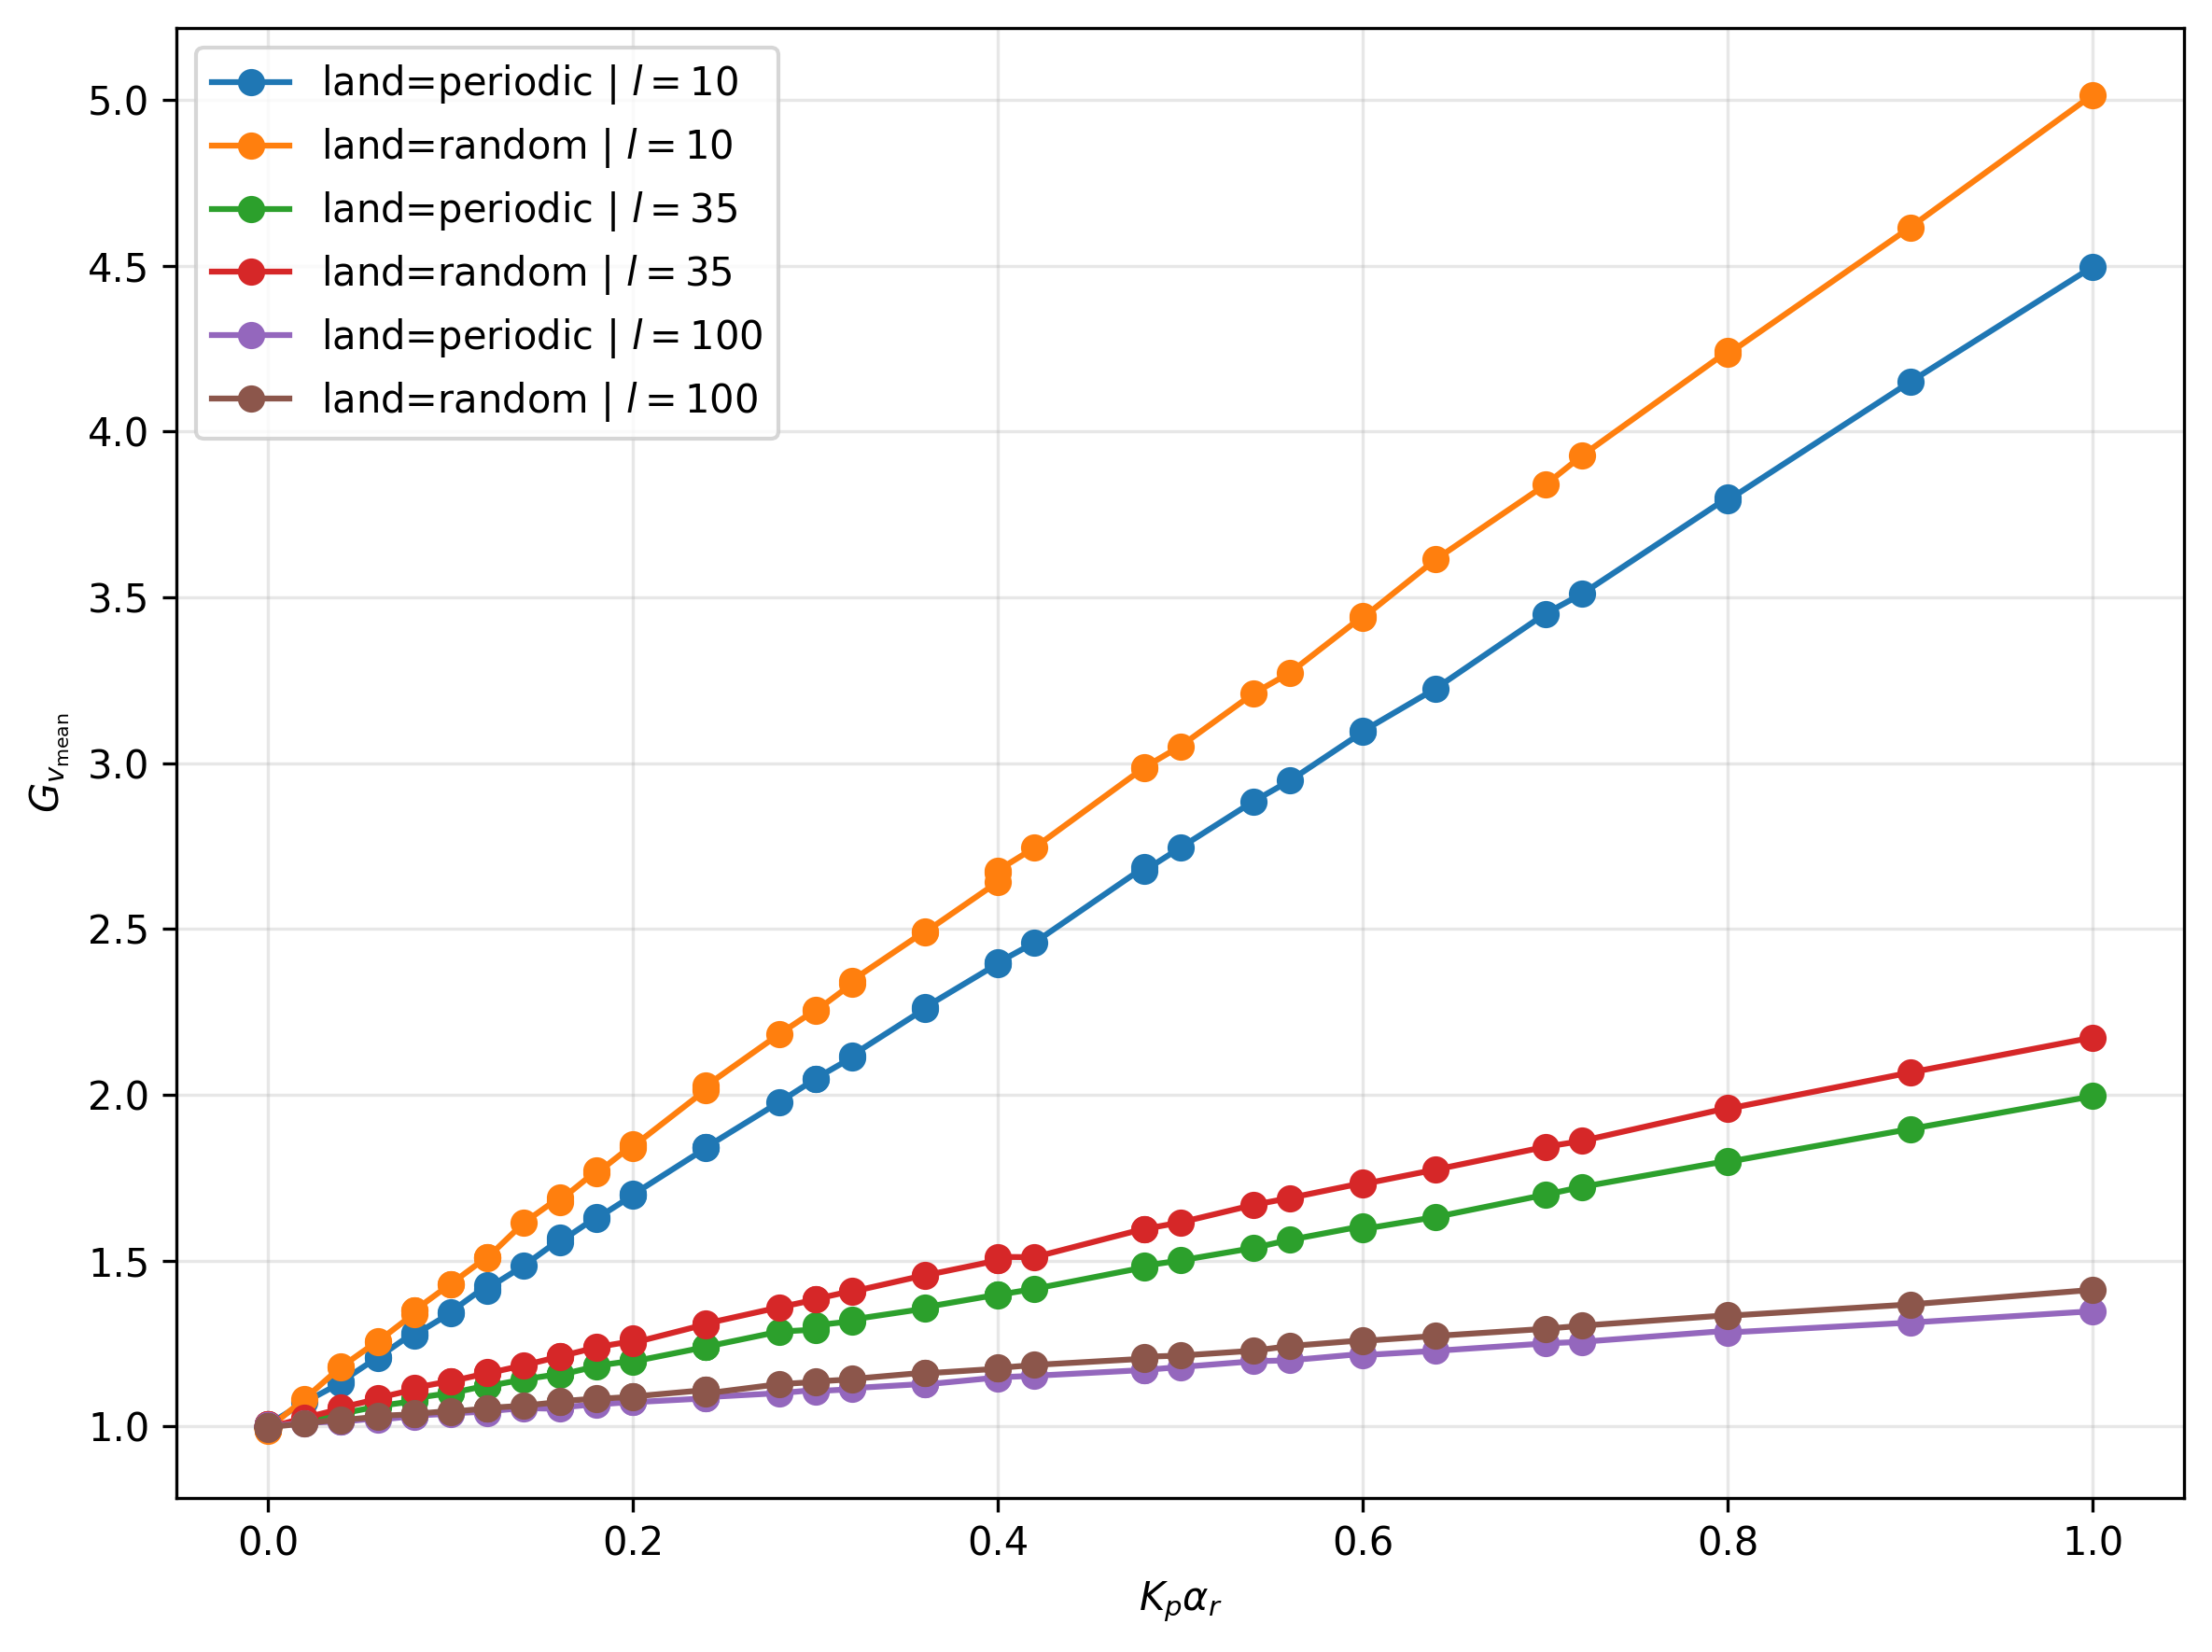

In [18]:
plt.figure(figsize=(8, 6), dpi=300)

ls = np.unique(df_passive["l"].to_numpy())

for l in ls:
    for land in landscapes:

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )

        v_base = df_passive.filter(
            (pl.col("alphar") == 0) &
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )["v_mean"].to_numpy()[0]

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        gain = df_land["v_mean"].to_numpy() / v_base
        print(len(gain))

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            gain[order],
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$G_{v_{\mathrm{mean}}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()

# Passive : bp

[2.60169286e-01 2.31731820e-01 2.39045994e-01 2.15625931e-01
 2.41737295e-01 2.41708840e-01 2.52919576e-01 2.68964629e-01
 2.52944061e-01 2.28875287e-01 2.22714655e-01 2.33005091e-01
 4.18702878e-01 6.98645277e-01 1.11404615e+00 1.74477757e+00
 2.47897182e+00 3.34817830e+00 4.71682826e+00 6.44887616e+00
 7.83493361e+00 1.05195736e+01 2.33732983e-01 6.41426365e-01
 1.64874440e+00 3.54958663e+00 6.28942583e+00 1.07505121e+01
 1.62929425e+01 2.34712307e+01 3.20543231e+01 4.29250005e+01
 5.43492065e+01 2.65437875e-01 1.08612599e+00 3.36771183e+00
 8.04335789e+00 1.65830172e+01 2.74122497e+01 4.24052366e+01
 6.11681906e+01 8.31269652e+01 1.07838046e+02 1.34290566e+02
 2.37319351e-01 1.62723374e+00 6.39259912e+00 1.62804006e+01
 3.17422281e+01 5.44691985e+01 8.26006792e+01 1.14807114e+02
 1.51519356e+02 1.90137913e+02 2.31152069e+02 2.25984084e-01
 2.32745541e+00 1.05407248e+01 2.75983506e+01 5.49047020e+01
 8.98519811e+01 1.33231890e+02 1.80372018e+02 2.30759579e+02
 2.84322552e+02 3.364292

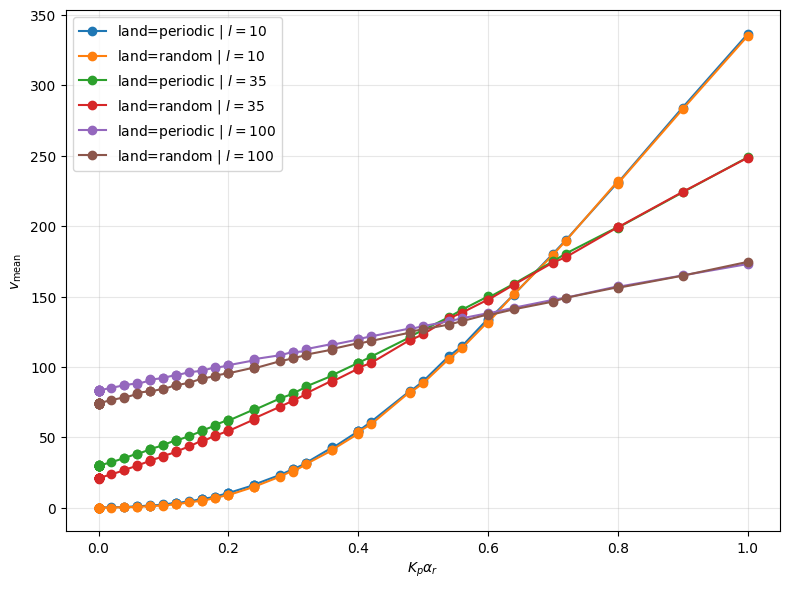

s=[35] | μ=[150] | θ=[100]


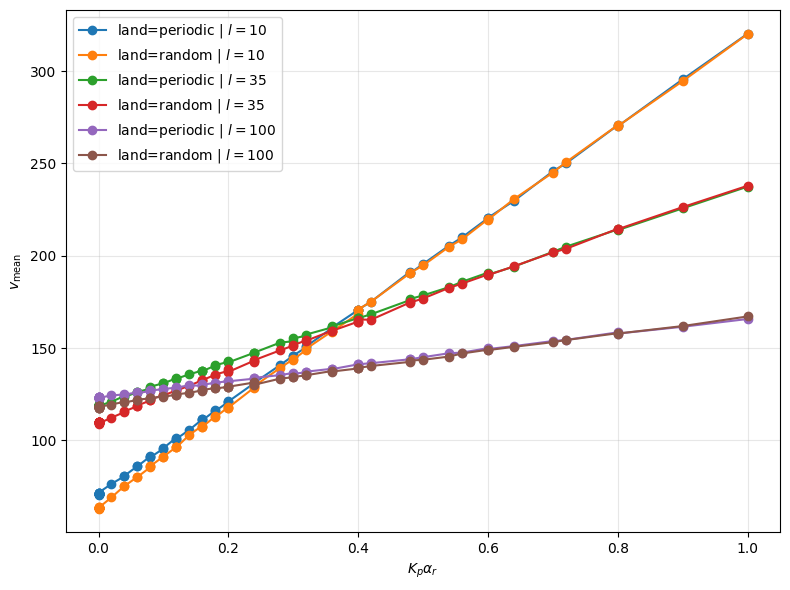

s=[35] | μ=[150] | θ=[100]


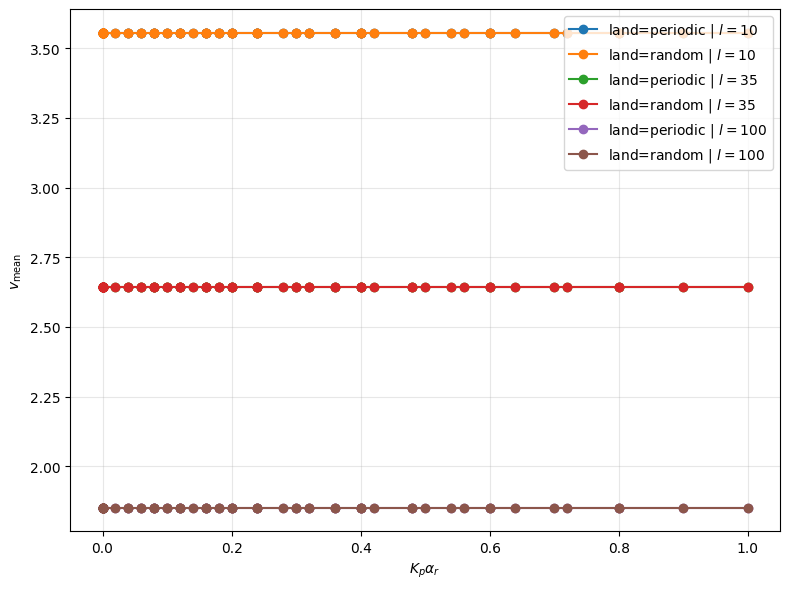

In [19]:
# -- Librairies
import matplotlib.pyplot as plt
import polars as pl
import numpy as np


# -- Second method
plt.figure(figsize=(8, 6))
ls = np.unique(df_passive["l"].to_numpy())

for l in ls:
    for land in landscapes:

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        v_mean_land = df_land["vc_mean"].to_numpy()
        print(v_mean_land)

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            v_mean_land[order],
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()


# -- First method
plt.figure(figsize=(8, 6))
ls      = np.unique(df_passive["l"].to_numpy())
s       = np.unique(df_passive["s"].to_numpy())
mu      = np.unique(df_passive["mu"].to_numpy())
theta   = np.unique(df_passive["theta"].to_numpy())

print(f"s={s} | μ={mu} | θ={theta}")

for l in ls:

    c = (150 + l) / (35 + l)

    for land in landscapes:

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        v_mean      = df_land["v_mean"].to_numpy()
        v_mean_c    = v_mean * c

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            v_mean_c[order],
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()    


# -- First method WITHOUT ALPHA C
plt.figure(figsize=(8, 6))
ls      = np.unique(df_passive["l"].to_numpy())
s       = np.unique(df_passive["s"].to_numpy())
mu      = np.unique(df_passive["mu"].to_numpy())
theta   = np.unique(df_passive["theta"].to_numpy())

print(f"s={s} | μ={mu} | θ={theta}")

for l in ls:

    c = (150 + l) / (35 + l)

    for land in landscapes:

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        v_mean      = df_land["v_mean"].to_numpy()
        alphac     = df_land["v_mean"].to_numpy()
        v_mean_c    = v_mean * c / alphac

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            v_mean_c[order],
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()  

In [38]:
150 * 160/45 * 0.60

320.0

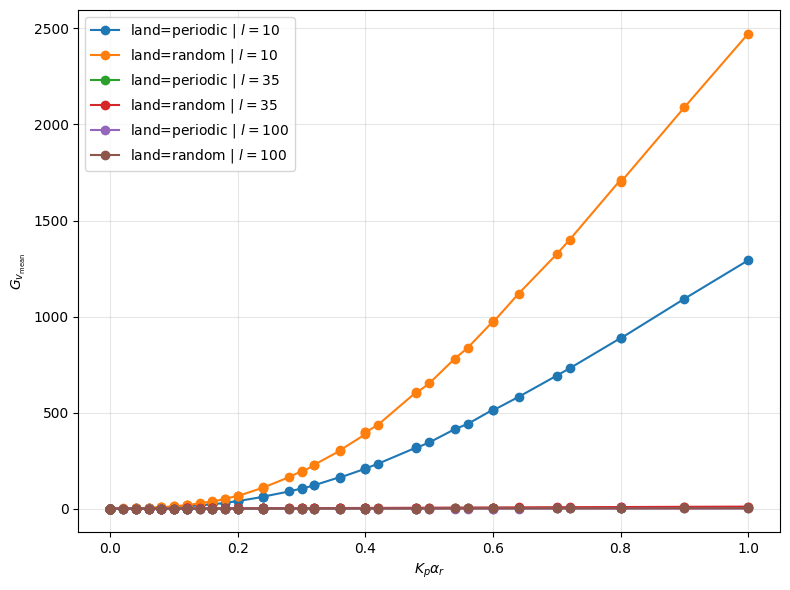

In [37]:
plt.figure(figsize=(8, 6))

ls = np.unique(df_passive["l"].to_numpy())

for l in ls:
    for land in landscapes:

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )

        v_base = df_passive.filter(
            (pl.col("alphar") == 0) &
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )["vc_mean"].to_numpy()[0]

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        gain = df_land["vc_mean"].to_numpy() / v_base

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            gain[order],
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$G_{v_{\mathrm{mean}}}$")
plt.grid(True, alpha=0.30, which="both")
# plt.loglog(True)
plt.legend()
plt.tight_layout()
plt.show()

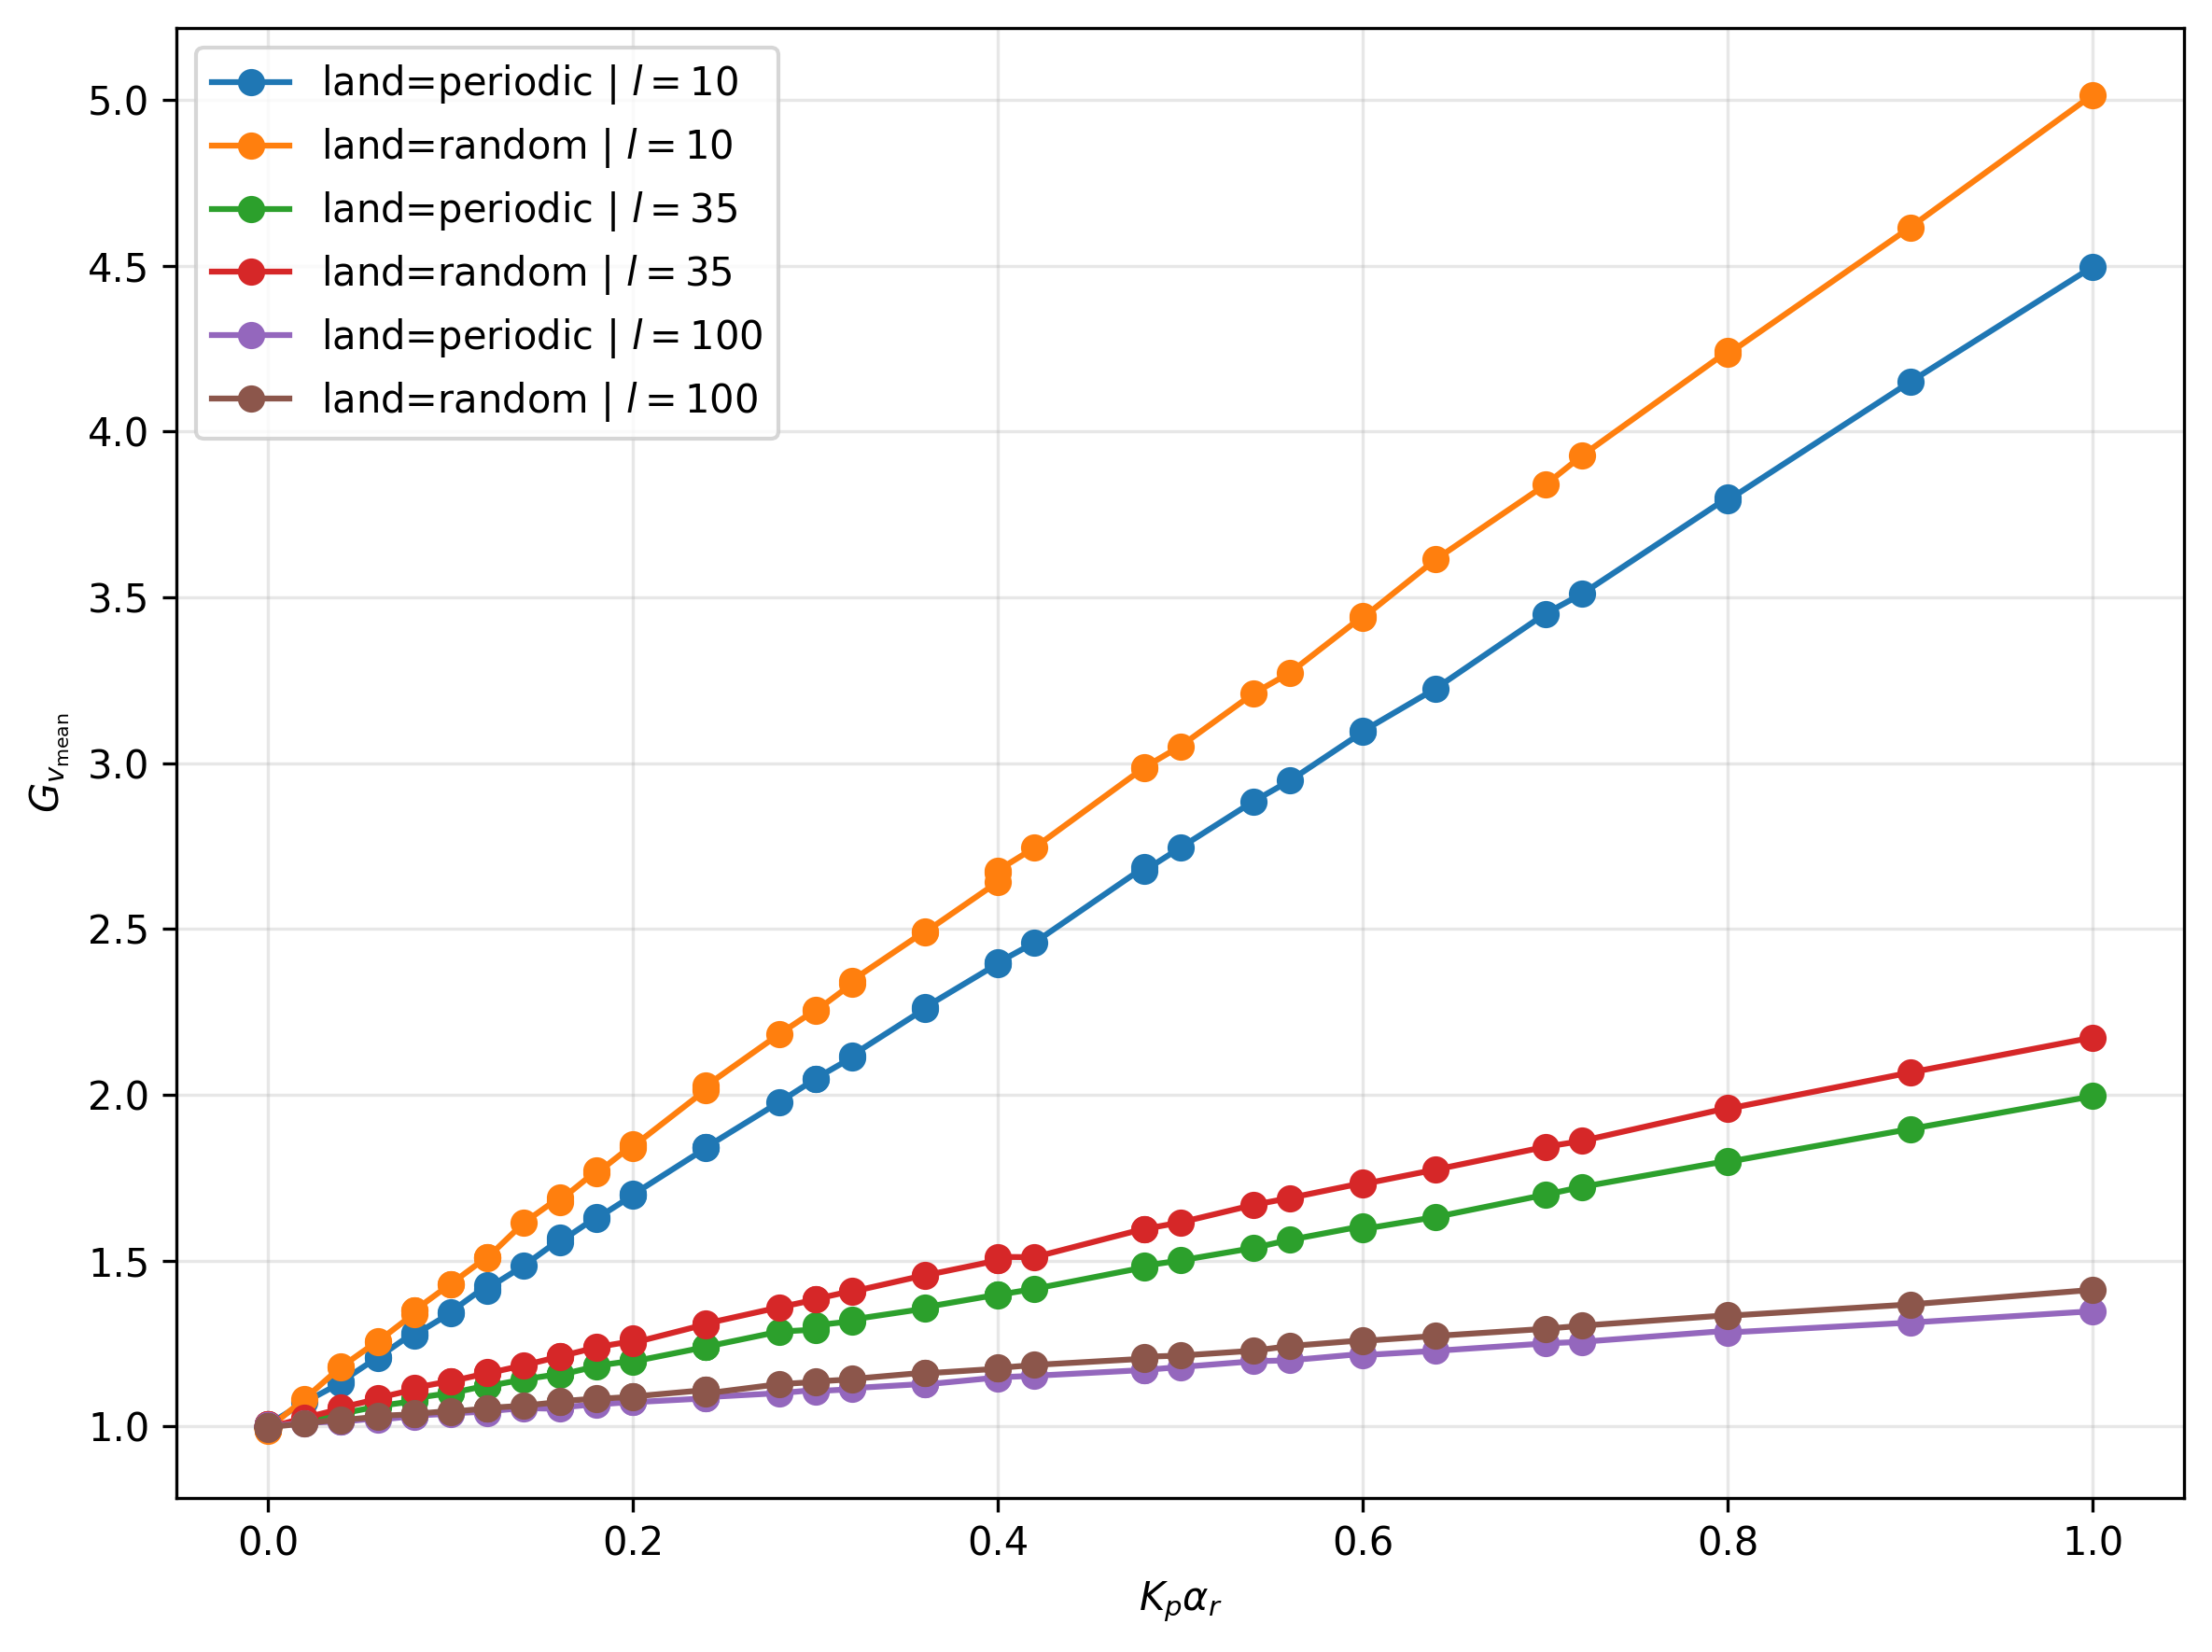

In [36]:
plt.figure(figsize=(8, 6), dpi=300)

ls      = np.unique(df_passive["l"].to_numpy())
s       = np.unique(df_passive["s"].to_numpy())
mu      = np.unique(df_passive["mu"].to_numpy())
theta   = np.unique(df_passive["theta"].to_numpy())

for l in ls:

    c = (150 + l) / (35 + l)

    for land in landscapes:

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )

        v_base_c = df_passive.filter(
            (pl.col("alphar") == 0) &
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )["v_mean"].to_numpy()[0] * c

        v_mean_c = df_land["v_mean"].to_numpy() * c

        gain =  v_mean_c / v_base_c

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            gain[order],
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$G_{v_{\mathrm{mean}}}$")
plt.grid(True, alpha=0.30)
plt.legend()
# plt.loglog(True)
plt.tight_layout()
plt.show()

# Active no mémo

In [26]:
# - Actifull -----
df_actifull = df_fact.filter(pl.col("mode") == "actifull")
print(df_actifull)

shape: (1_782, 61)
┌──────┬──────┬──────────┬───────┬───┬───────┬──────────┬──────────┬───────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ dx_mp ┆ dt_mean  ┆ dt_med   ┆ dt_mp │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---   ┆ ---      ┆ ---      ┆ ---   │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ f64   ┆ f64      ┆ f64      ┆ f64   │
╞══════╪══════╪══════════╪═══════╪═══╪═══════╪══════════╪══════════╪═══════╡
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 91.5  ┆ 0.999241 ┆ 0.837845 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 73.5  ┆ 0.996669 ┆ 0.836689 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 98.5  ┆ 0.998465 ┆ 0.838713 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 74.5  ┆ 1.001269 ┆ 0.840778 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 82.5  ┆ 1.000149 ┆ 0.839989 ┆ 0.5   │
│ …    ┆ …    ┆ …        ┆ …     ┆ … ┆ …     ┆ …        ┆ …        ┆ …     │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 90.5  ┆ 0.987432 ┆ 0.827666 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 78.5  ┆ 1.004093 ┆

In [27]:
columns = [
    'algo', 'fact', 'mode', 'dstr', 
    'land', 's', 'l', 'bpmin', 
    'mu', 'theta', 'alphaf', 
    'alphao', 'beta', 'rcapt', 'rrest', 'alphac', 'alphad', 
    'alphar', 'krel', 'Kp', 'Kz'
]

for col in columns:
    print(f"Unique values of {col} : {np.unique(df_actifull[col])}")

landscapes = ["periodic", "random"]
df_actifull = df_actifull.filter(
    (pl.col("land").is_in(landscapes))
)
print(df_actifull)

Unique values of algo : ['2S']
Unique values of fact : [ True]
Unique values of mode : ['actifull']
Unique values of dstr : [False]
Unique values of land : ['homogen' 'periodic' 'random']
Unique values of s : [35]
Unique values of l : [ 10  35 100]
Unique values of bpmin : [0]
Unique values of mu : [150]
Unique values of theta : [100]
Unique values of alphaf : [1.]
Unique values of alphao : [0.]
Unique values of beta : [0.]
Unique values of rcapt : [2.]
Unique values of rrest : [2.]
Unique values of alphac : [0.6]
Unique values of alphad : [0.]
Unique values of alphar : [0.  0.2 0.4 0.6 0.8 1. ]
Unique values of krel : [1.]
Unique values of Kp : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Unique values of Kz : [0.  0.5 1. ]
shape: (1_188, 61)
┌──────┬──────┬──────────┬───────┬───┬───────┬──────────┬──────────┬───────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ dx_mp ┆ dt_mean  ┆ dt_med   ┆ dt_mp │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---   ┆ ---      ┆ ---      ┆ ---   │
│ str  ┆ bool 

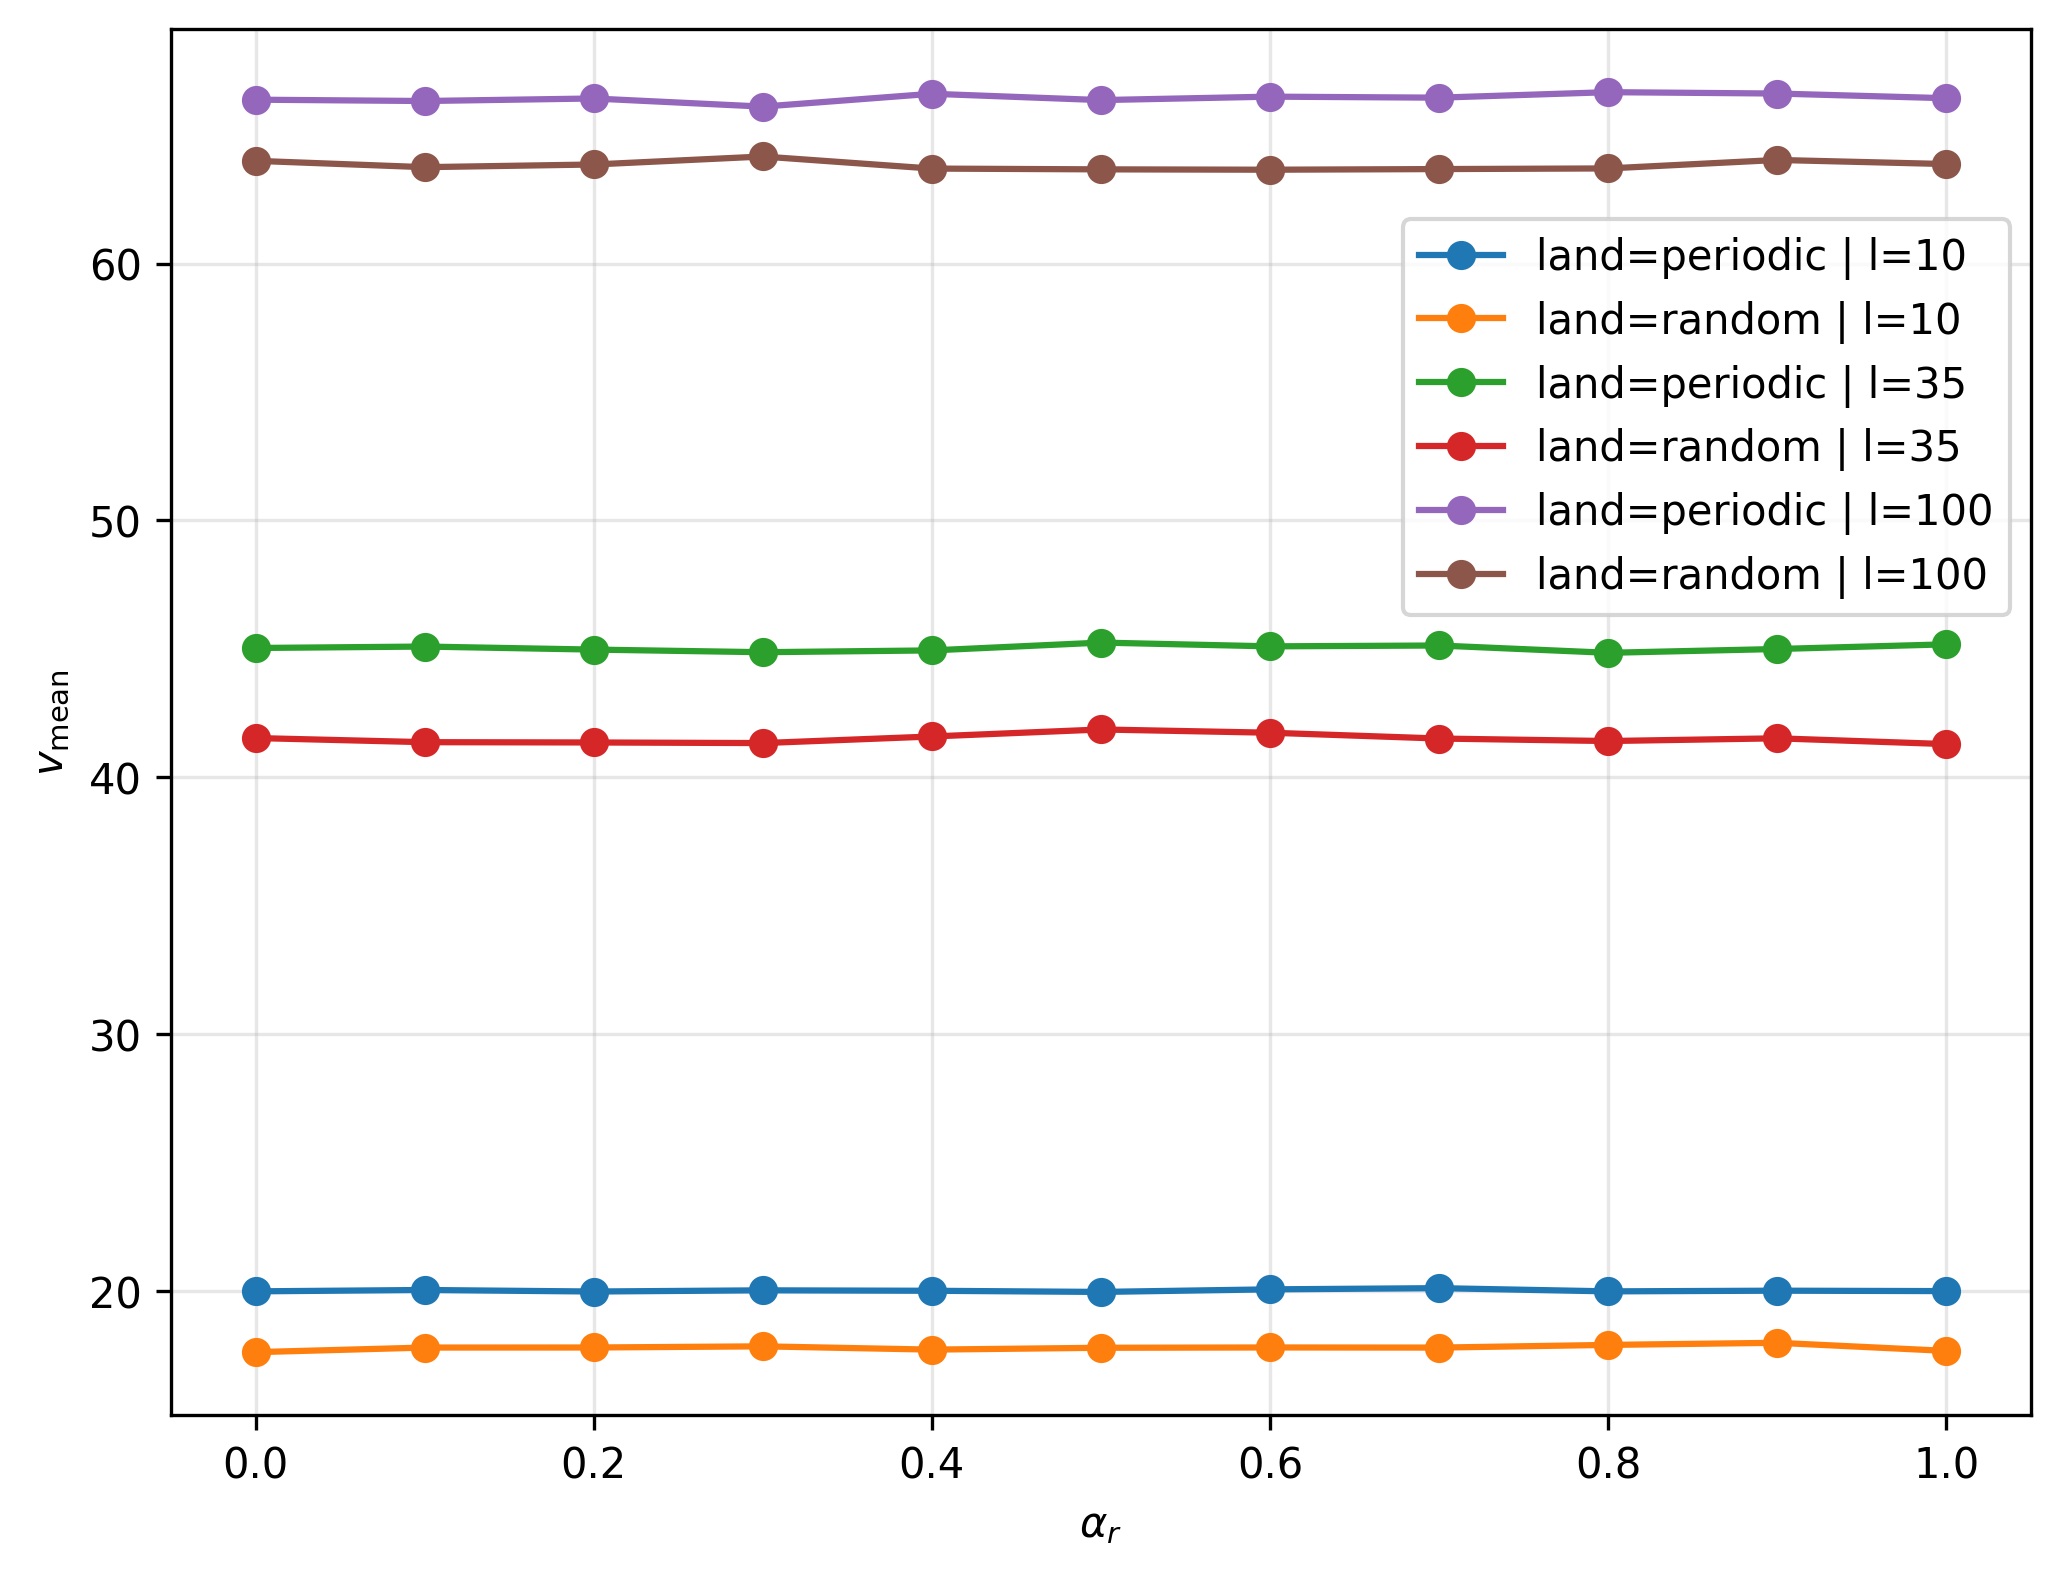

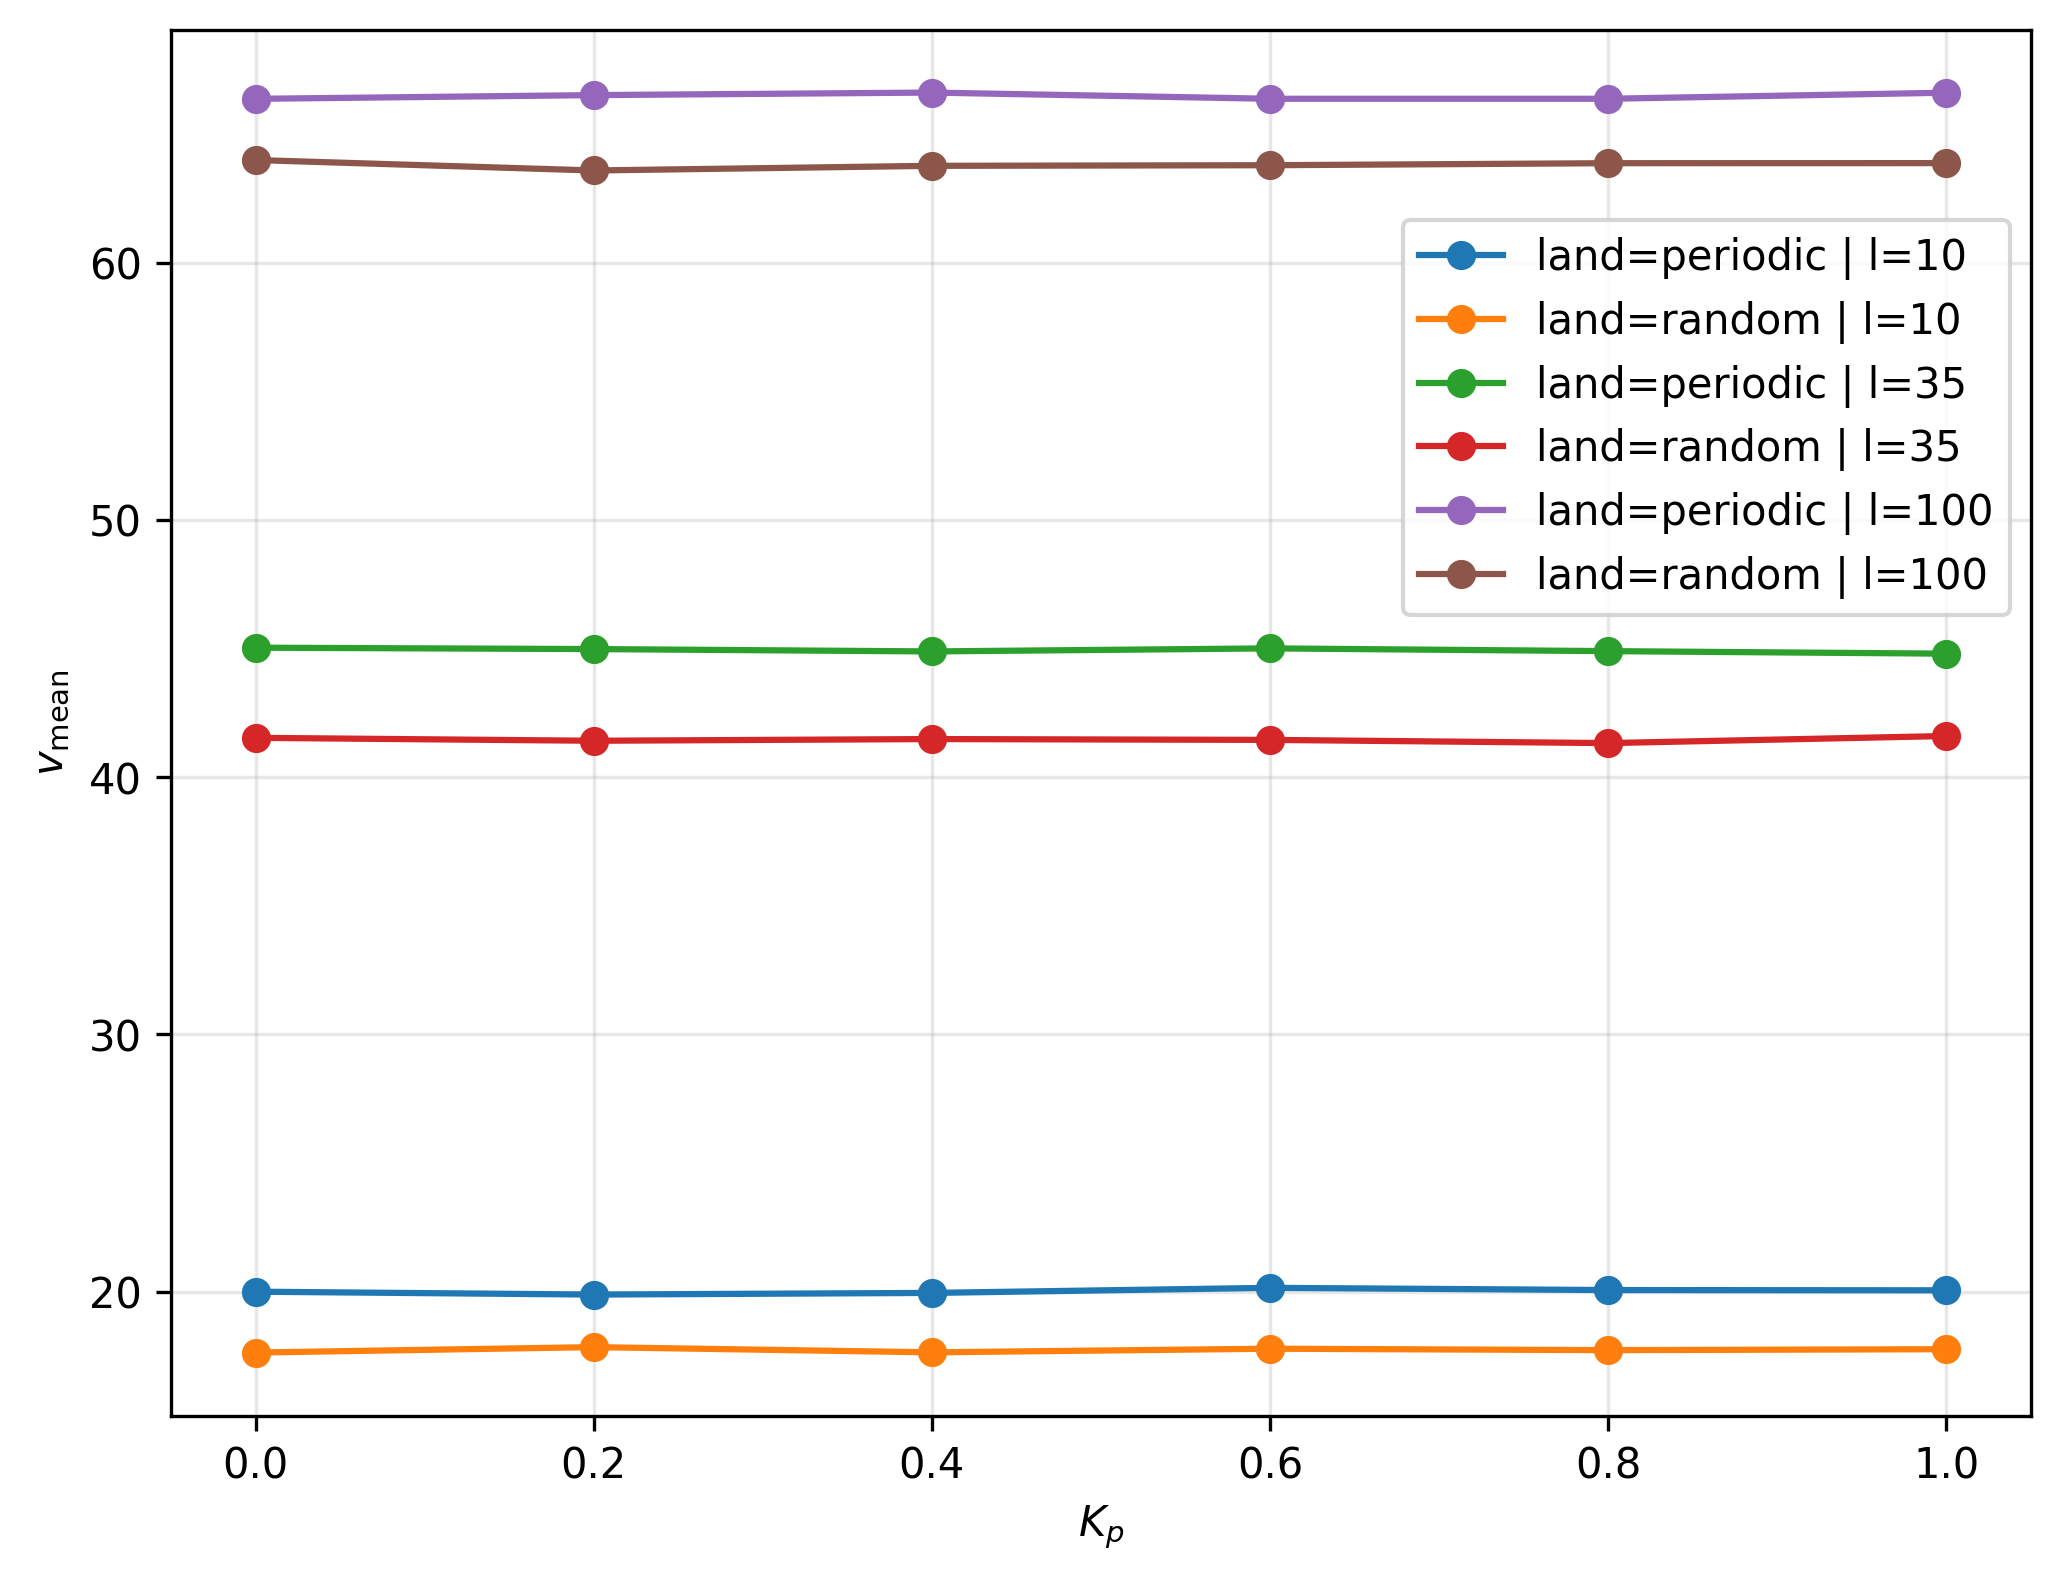

In [28]:
plt.figure(figsize=(8,6), dpi=300)

alphar = 0

ls = np.unique(df_actifull["l"].to_numpy())

for l in ls:

    for land in landscapes :

        df_land = df_actifull.filter(
            (pl.col("land") == land) &
            (pl.col("alphar") == alphar) &
            (pl.col("l") == l) &
            (pl.col("Kz") == 0)
        )

        Kp      = df_land["Kp"].to_numpy()
        v_mean  = df_land["v_mean"].to_numpy()

        plt.plot(Kp, v_mean, label=f"land={land} | l={l}", marker = "o")

# plt.title(rf"$l={l}~|~\alpha_r = {alphar}$")
plt.xlabel(r"$\alpha_r$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend(
    loc="center right",
    bbox_to_anchor=(1, 0.72)
)
plt.show()


plt.figure(figsize=(8,6), dpi=300)

Kp = 0
ls = np.unique(df_actifull["l"].to_numpy())

for l in ls:

    for land in landscapes :

        df_land = df_actifull.filter(
            (pl.col("land") == land) &
            (pl.col("Kp") == Kp) &
            (pl.col("l") == l) &
            (pl.col("Kz") == 0)
        )

        alphar  = df_land["alphar"].to_numpy()
        v_mean  = df_land["v_mean"].to_numpy()

        plt.plot(alphar, v_mean, label=f"land={land} | l={l}", marker = "o")

# plt.title(rf"$l={l}~|~K_p = {Kp}$")
plt.xlabel(r"$K_p$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend(
    loc="center right",
    bbox_to_anchor=(1, 0.72)
)
plt.show()

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 

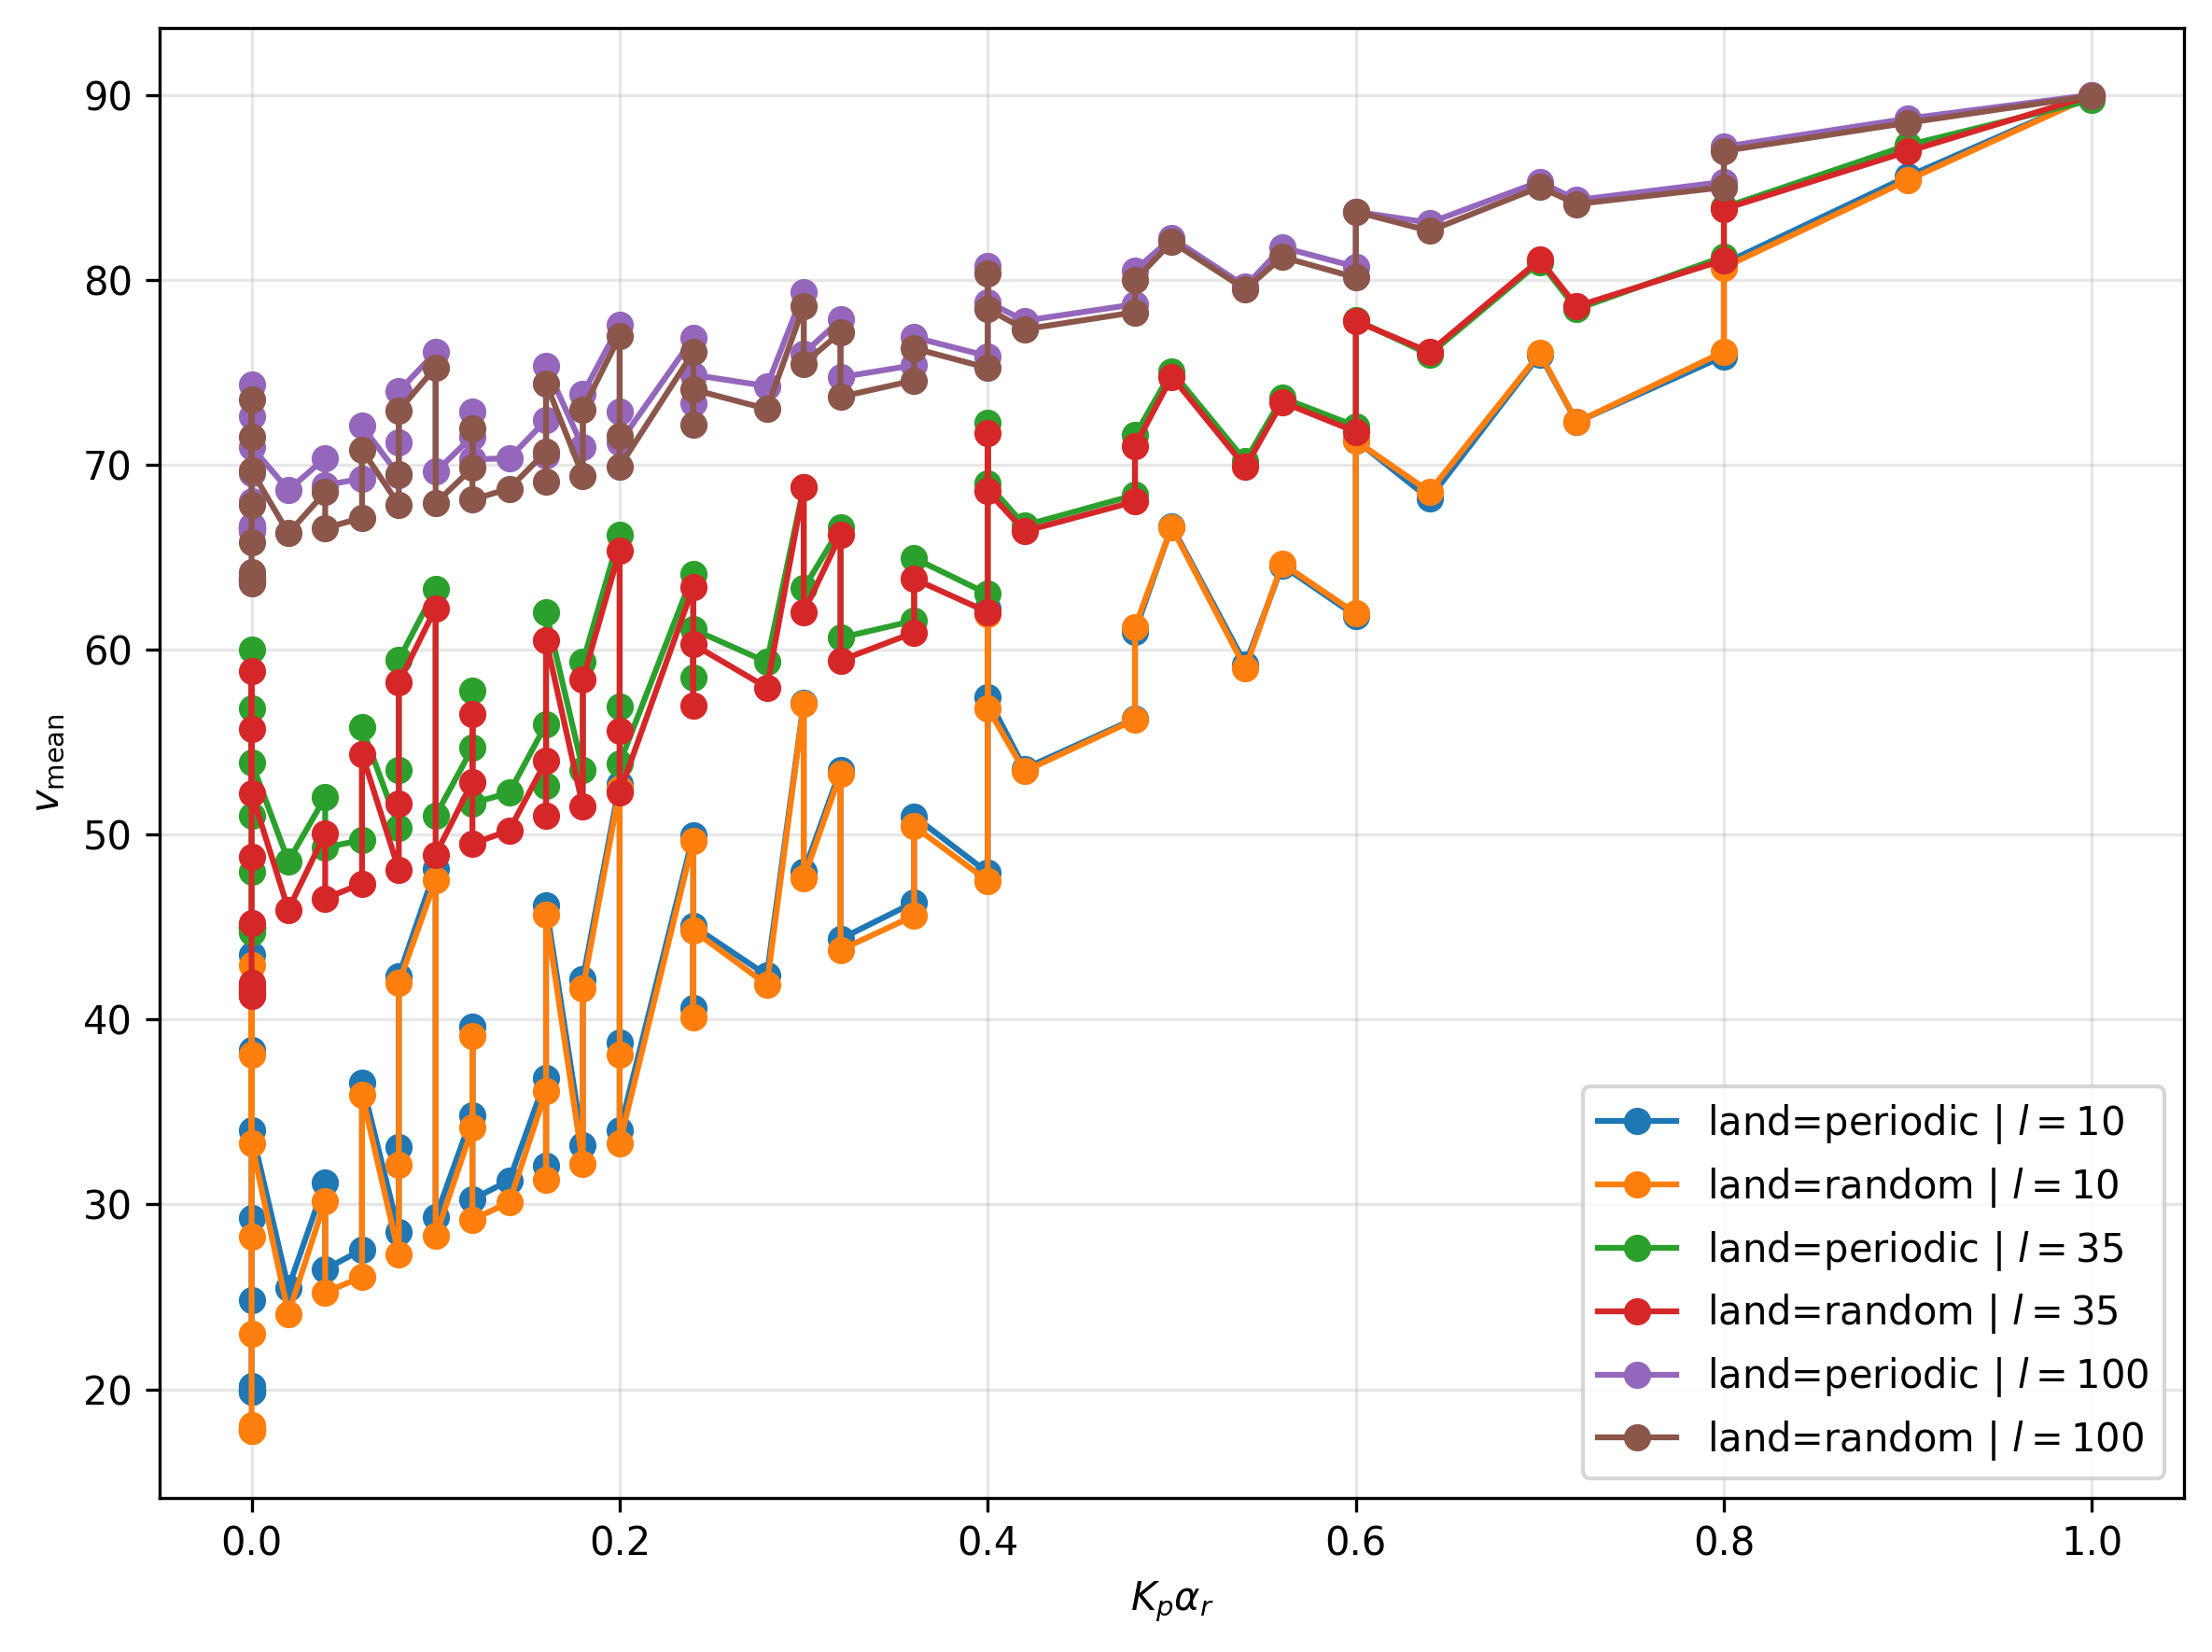

In [ ]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

plt.figure(figsize=(8, 6), dpi=300)

ls = np.unique(df_passive["l"].to_numpy())

for l in ls:
    for land in landscapes:

        df_land = df_actifull.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l) &
            # (pl.col("alphar") == 1) &
            (pl.col("Kz") == 1)
        )

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        v_mean_land = df_land["v_mean"].to_numpy()

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            v_mean_land[order],
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()

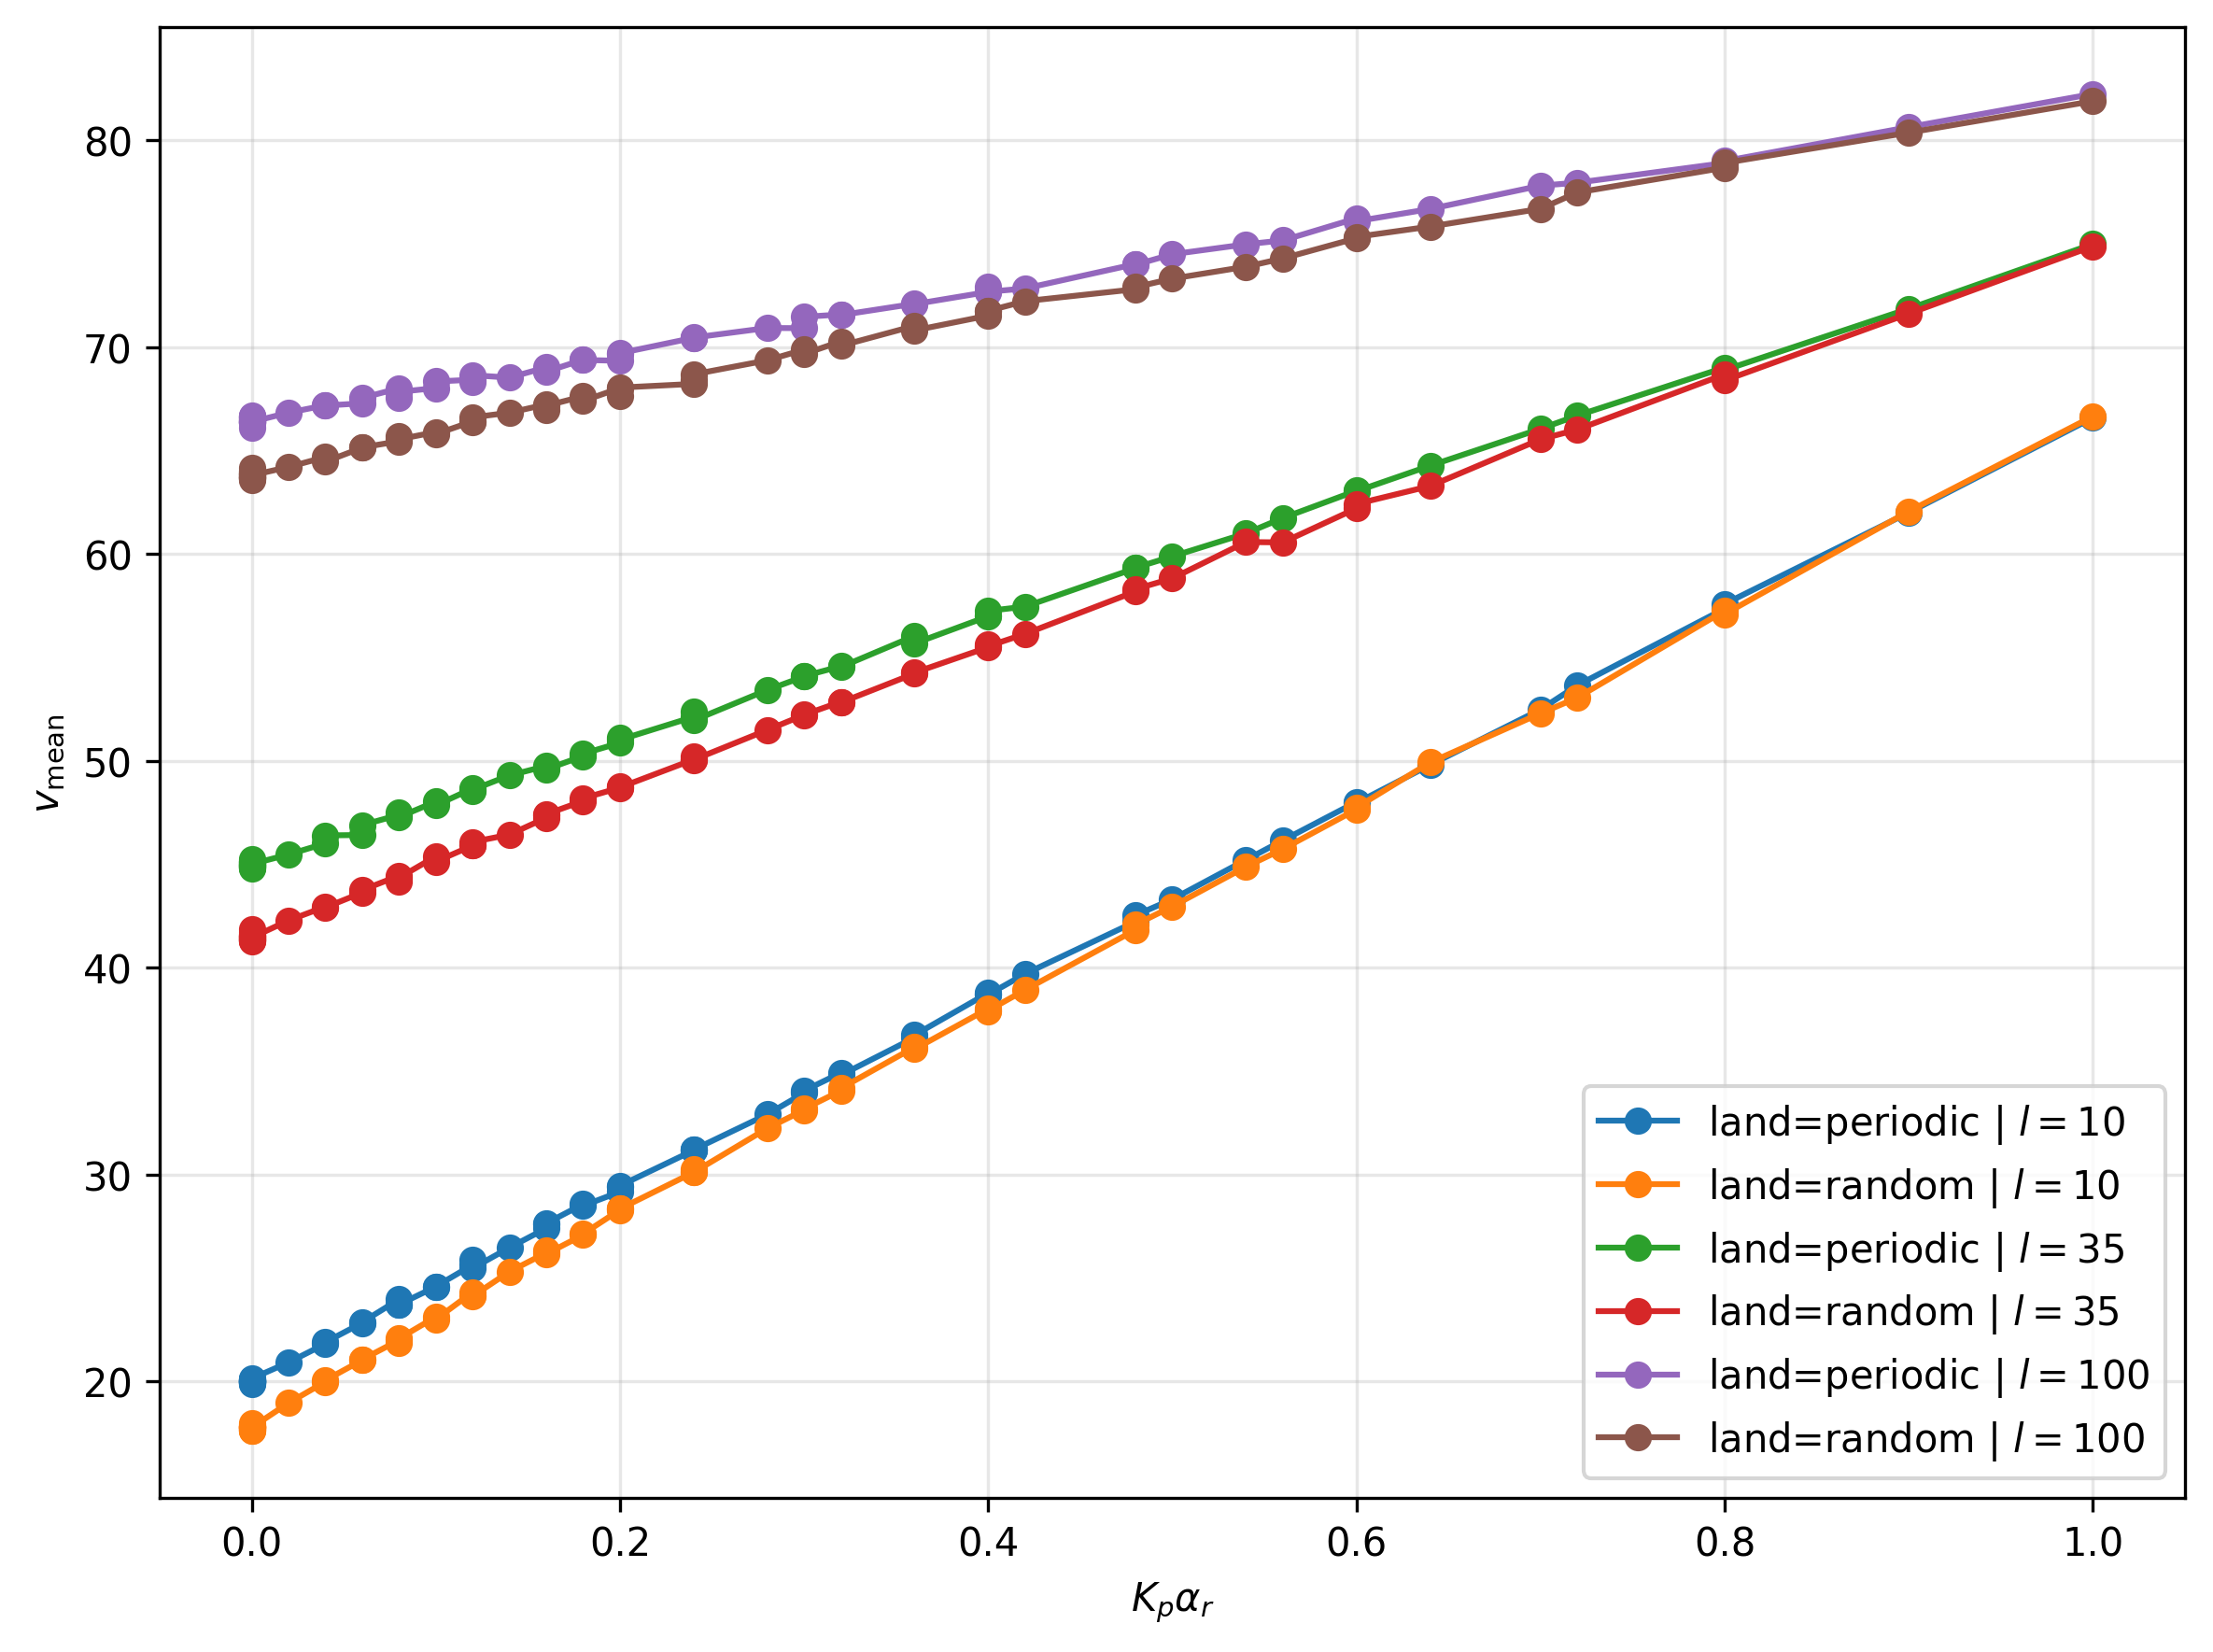

In [43]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

plt.figure(figsize=(8, 6), dpi=300)

ls = np.unique(df_actifull["l"].to_numpy())

for l in ls:
    for land in landscapes:

        df_land = df_actifull.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l) &
            (pl.col("Kz") == 0)
            # (pl.col("Kp") == 1)
        )

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        v_mean_land = df_land["v_mean"].to_numpy()

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            v_mean_land[order],
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()

In [65]:
# Librairies
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from nucleo.io.reading import reading_all_parquet

# Racine
root_work = "/home/nicolas/Documents/Workspace/nucleo/outputs/FACT__PC__2026-09-15/"

# # Charge tout
# lazy_work = pl.scan_parquet(
#     f"{root_work}/**/**/*.parquet"
# )
# df_work = lazy_work.collect()

# Charge que les Float / Int / Str
df_work = reading_all_parquet(root_work)

print(df_work)

columns = [
    'algo', 'fact', 'mode', 'dstr', 
    'land', 's', 'l', 'bpmin', 
    'mu', 'theta', 'alphaf', 
    'alphao', 'beta', 'rcapt', 'rrest', 'alphac', 'alphad', 
    'alphar', 'krel', 'Kp', 'Kz'
]

for col in columns:
    print(f"Unique values of {col} : {np.unique(df_work[col])}")
print(df_work.columns)

shape: (594, 61)
┌──────┬──────┬──────────┬───────┬───┬───────┬──────────┬──────────┬───────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ dx_mp ┆ dt_mean  ┆ dt_med   ┆ dt_mp │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---   ┆ ---      ┆ ---      ┆ ---   │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ f64   ┆ f64      ┆ f64      ┆ f64   │
╞══════╪══════╪══════════╪═══════╪═══╪═══════╪══════════╪══════════╪═══════╡
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 179.5 ┆ 10.11455 ┆ 6.778    ┆ 1.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 89.5  ┆ 5.347406 ┆ 3.603624 ┆ 1.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 45.5  ┆ 1.00922  ┆ 0.836121 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 44.5  ┆ 8.60599  ┆ 6.250626 ┆ 2.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 135.5 ┆ 5.441    ┆ 4.046371 ┆ 2.5   │
│ …    ┆ …    ┆ …        ┆ …     ┆ … ┆ …     ┆ …        ┆ …        ┆ …     │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 102.5 ┆ 5.556951 ┆ 4.127068 ┆ 1.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 93.5  ┆ 0.988511 ┆ 0

/home/nicolas/Documents/Workspace/nucleo/src/nucleo/io/reading.py:143: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  cols = _scalar_column_names(lf.schema)


shape: (22, 61)
┌──────┬──────┬──────────┬───────┬───┬───────┬──────────┬──────────┬───────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ dx_mp ┆ dt_mean  ┆ dt_med   ┆ dt_mp │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---   ┆ ---      ┆ ---      ┆ ---   │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ f64   ┆ f64      ┆ f64      ┆ f64   │
╞══════╪══════╪══════════╪═══════╪═══╪═══════╪══════════╪══════════╪═══════╡
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 89.5  ┆ 0.972708 ┆ 0.81875  ┆ 0.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 91.5  ┆ 0.981328 ┆ 0.848793 ┆ 0.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 136.5 ┆ 1.03791  ┆ 0.849883 ┆ 0.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 90.5  ┆ 0.99707  ┆ 0.849274 ┆ 0.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 87.5  ┆ 0.985914 ┆ 0.840157 ┆ 0.5   │
│ …    ┆ …    ┆ …        ┆ …     ┆ … ┆ …     ┆ …        ┆ …        ┆ …     │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 47.5  ┆ 0.993134 ┆ 0.82539  ┆ 0.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 47.5  ┆ 0.981859 ┆ 0.

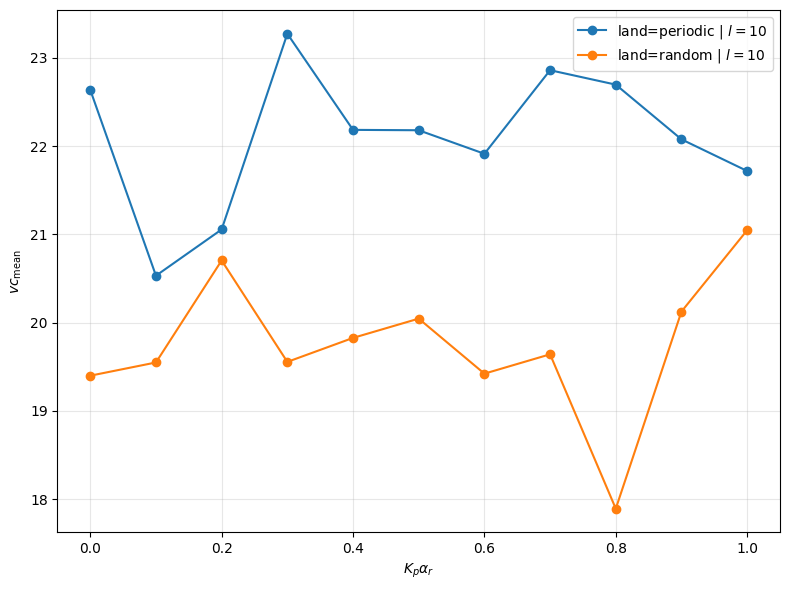

In [ ]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

plt.figure(figsize=(8, 6))

df_work_passive = df_work.filter(
    (pl.col("mode")  == "passfull") &
    (pl.col("rrest") == 2.00) &
    (pl.col("Kz") == 0.00)
)

print(df_work_passive)

ls = np.unique(df_work_passive["l"].to_numpy())
lands = np.unique(df_work_passive["land"].to_numpy())
print(ls, lands)

for l in ls:
    for land in lands:

        df_land = df_work_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l) 
            # (pl.col("alphar") == 1) &
        )
        
        Kp = df_land["Kp"].to_numpy()
        v_mean = df_land["v_mean"].to_numpy()


        plt.plot(
            Kp,
            v_mean,
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$vc_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()

# Active mémo

In [14]:
# - Actifull -----
df_actimemo = df_fact.filter(pl.col("mode") == "actimemo")
print(df_actimemo)

shape: (1_782, 61)
┌──────┬──────┬──────────┬───────┬───┬───────┬──────────┬──────────┬───────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ dx_mp ┆ dt_mean  ┆ dt_med   ┆ dt_mp │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---   ┆ ---      ┆ ---      ┆ ---   │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ f64   ┆ f64      ┆ f64      ┆ f64   │
╞══════╪══════╪══════════╪═══════╪═══╪═══════╪══════════╪══════════╪═══════╡
│ 2S   ┆ true ┆ actimemo ┆ false ┆ … ┆ 76.5  ┆ 1.001531 ┆ 0.842224 ┆ 0.5   │
│ 2S   ┆ true ┆ actimemo ┆ false ┆ … ┆ 74.5  ┆ 1.000219 ┆ 0.840694 ┆ 0.5   │
│ 2S   ┆ true ┆ actimemo ┆ false ┆ … ┆ 81.5  ┆ 1.001264 ┆ 0.839951 ┆ 0.5   │
│ 2S   ┆ true ┆ actimemo ┆ false ┆ … ┆ 72.5  ┆ 0.998398 ┆ 0.837447 ┆ 0.5   │
│ 2S   ┆ true ┆ actimemo ┆ false ┆ … ┆ 89.5  ┆ 0.995786 ┆ 0.835434 ┆ 0.5   │
│ …    ┆ …    ┆ …        ┆ …     ┆ … ┆ …     ┆ …        ┆ …        ┆ …     │
│ 2S   ┆ true ┆ actimemo ┆ false ┆ … ┆ 94.5  ┆ 0.987547 ┆ 0.82749  ┆ 0.5   │
│ 2S   ┆ true ┆ actimemo ┆ false ┆ … ┆ 98.5  ┆ 1.000654 ┆

# .